# <font color="steelblue">Regresión logística para clasificación binaria</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**

**Fecha última edición**: 05/06/2026

**Licencia**: <a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a>

No olvides hacer una copia si deseas utilizarlo.

In [29]:
# @title Cargar configuración del cuaderno
!pip install gdown
!pip install --upgrade kagglehub
!pip install lightgbm xgboost

# Análisis numérico
import numpy as np
import pandas as pd
import math, random
import warnings
warnings.filterwarnings('ignore')

# Gráficos
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_theme(style='whitegrid')
%config InlineBackend.figure_format = 'retina'

import os, zipfile, gdown, kagglehub

# Funciones del curso
from urllib.request import urlretrieve
for fichero in ['preprocesar.py', 'evaluar_clasificadores.py', 'pca_funciones.py', 'auto_ML.py']:
    urlretrieve(f'https://raw.githubusercontent.com/ia4legos/MachineLearning/refs/heads/main/{fichero}', fichero)
from preprocesar import *
from evaluar_clasificadores import *
from pca_funciones import *
from auto_ML import *

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, learning_curve, GridSearchCV
from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             make_scorer, precision_score, recall_score, f1_score)
RNG = 42

# <font color="steelblue">Introducción</font>

La **regresión logística** es uno de los modelos de clasificación más usados y, pese a su nombre, **clasifica** (no predice valores continuos). Es un modelo **lineal** y **probabilístico**: a diferencia de muchos otros clasificadores, proporciona una **ecuación explícita** que da la **probabilidad** de pertenecer a cada clase en función de las variables predictoras, lo que la hace especialmente **interpretable**. En este cuaderno tratamos el caso de **respuesta binaria** ($K=2$ clases).

# <font color="steelblue">1. De la regresión lineal a la clasificación: la función logística</font>

En un problema de clasificación binaria tenemos una respuesta $y\in\{0,1\}$ (las dos clases, p. ej. "enfermo/sano") y un conjunto de predictoras $x=(x_1,\dots,x_p)$. Querríamos modelar la **probabilidad** de la clase positiva, $p(x)=P(y=1\mid x)$, que por definición vive en $[0,1]$.

Si usáramos una **regresión lineal** $\,\hat y = w^\top x + b\,$ tendríamos dos problemas: (1) su salida recorre todo $(-\infty,+\infty)$, así que produciría "probabilidades" negativas o mayores que 1; y (2) ajustar una recta a una variable que solo vale 0 o 1 da un ajuste pobre y predicciones sin sentido. Necesitamos una función que **transforme** la combinación lineal $z=w^\top x+b$ en una probabilidad válida.



## <font color="steelblue">1.1. La función logística (sigmoide)</font>

Esa función es la **logística** o **sigmoide**:

$$\sigma(z)=\frac{1}{1+e^{-z}},\qquad z = w^\top x + b .$$

Sus propiedades explican por qué es la elección natural:

* **Rango $(0,1)$**: cualquier número real se "aplasta" a una probabilidad válida.
* **Forma de S**: crece de forma **monótona**; vale casi 0 para $z$ muy negativo, exactamente $0.5$ en $z=0$, y casi 1 para $z$ muy positivo. La transición es **suave**, no un escalón.
* **Simetría**: $\sigma(-z)=1-\sigma(z)$, de modo que la probabilidad de la clase 0 es simplemente $1-p(x)$.
* **Derivada sencilla**: $\sigma'(z)=\sigma(z)\,(1-\sigma(z))$, máxima en $z=0$ (donde el modelo es más "sensible") y casi nula en los extremos (donde ya está casi decidido). Esta propiedad es la que hace eficiente el ajuste por descenso de gradiente.

El modelo de regresión logística es, por tanto,

$$p(x)=\sigma(w^\top x + b)=\frac{1}{1+e^{-(w^\top x + b)}}.$$

La combinación lineal $z$ se suele llamar **puntuación** o *logit score*: cuanto mayor es $z$, más cerca de 1 está la probabilidad.

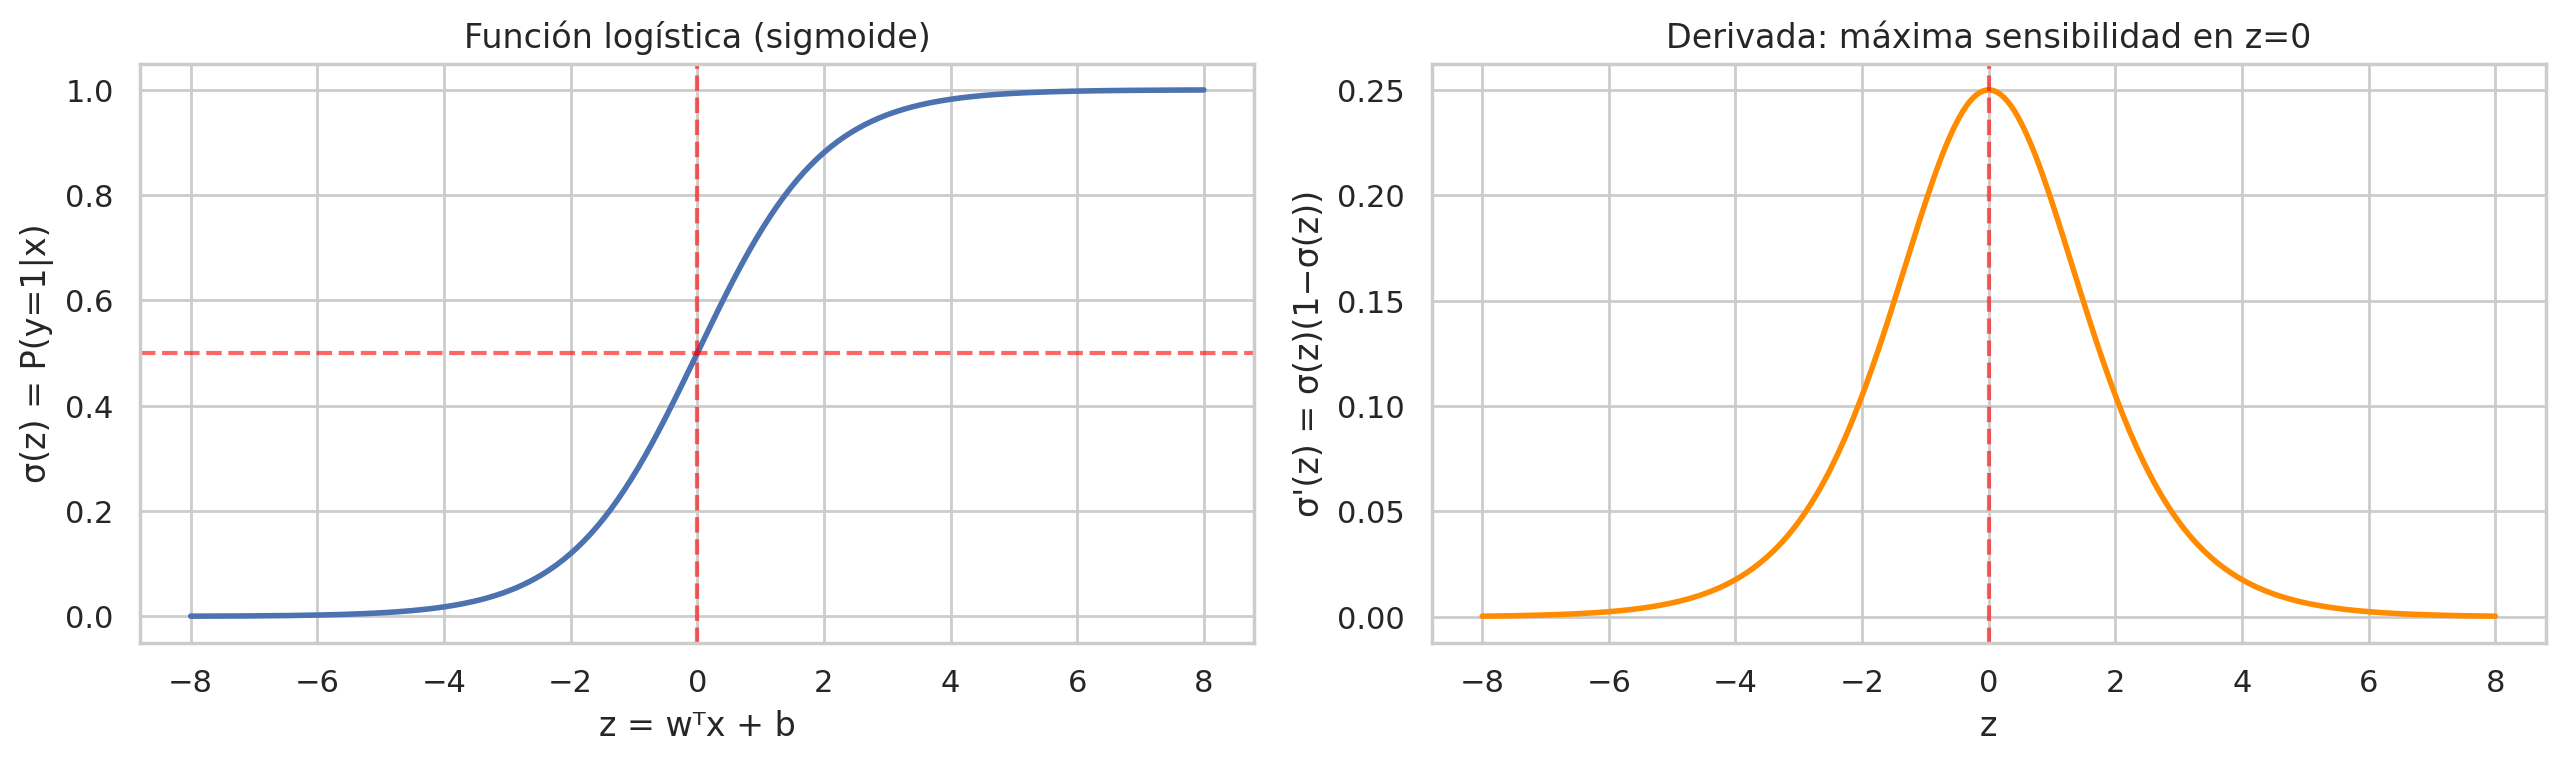

In [30]:
# La función sigmoide y su derivada
z = np.linspace(-8, 8, 300)
sig = 1/(1+np.exp(-z))
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(z, sig, lw=2); ax[0].axhline(0.5, color='red', ls='--', alpha=.6); ax[0].axvline(0, color='red', ls='--', alpha=.6)
ax[0].set_xlabel('z = wᵀx + b'); ax[0].set_ylabel('σ(z) = P(y=1|x)'); ax[0].set_title('Función logística (sigmoide)')
ax[1].plot(z, sig*(1-sig), lw=2, color='darkorange'); ax[1].axvline(0, color='red', ls='--', alpha=.6)
ax[1].set_xlabel('z'); ax[1].set_ylabel("σ'(z) = σ(z)(1−σ(z))"); ax[1].set_title('Derivada: máxima sensibilidad en z=0')
plt.tight_layout(); plt.show()

A la izquierda, la sigmoide convierte la puntuación lineal en probabilidad. A la derecha, su derivada muestra que el modelo es **más sensible** cerca de la frontera ($z=0$, $p=0.5$) y casi insensible en los extremos: una vez que una muestra está "claramente" en una clase, mover un poco sus variables apenas cambia la probabilidad.



## <font color="steelblue">1.2. Odds y logit: por qué el modelo es lineal</font>

La clave para interpretar el modelo son los **odds** (la "ventaja", cociente entre la probabilidad de la clase 1 y la de la clase 0):

$$\text{odds}(x)=\frac{p(x)}{1-p(x)}.$$

Los odds van de 0 a $+\infty$: valen 1 cuando $p=0.5$ (clases igual de probables), $<1$ cuando la clase 0 es más probable y $>1$ cuando lo es la clase 1. Si despejamos $p(x)$ del modelo y tomamos logaritmos, aparece una relación **lineal**: el **logaritmo de los odds** (la función **logit**) es

$$\operatorname{logit}(p)=\log\frac{p(x)}{1-p(x)} = w^\top x + b .$$

Es decir, **la regresión logística es una regresión lineal… pero sobre el logit (log-odds)**, no sobre la probabilidad. La función logística y la logit son **inversas** entre sí: una pasa de puntuación a probabilidad, la otra de probabilidad a puntuación. Esto explica a la vez por qué la **frontera** del modelo es lineal y por qué sus coeficientes se interpretan a través de los odds, como veremos ahora.

# <font color="steelblue">2. El modelo y la interpretación de los coeficientes (*odds ratios*)</font>

Como el logit es lineal, cada coeficiente $w_j$ tiene una lectura **directa y cuantitativa**. Supongamos que la variable $x_j$ **aumenta en una unidad** manteniendo las demás fijas. El logit cambia exactamente en $w_j$:

$$\operatorname{logit}(p)\ \longrightarrow\ \operatorname{logit}(p)+w_j .$$

Y como el logit es el **logaritmo** de los odds, sumar $w_j$ al logit equivale a **multiplicar los odds** por $e^{w_j}$. Esa cantidad se llama **odds ratio (OR)** de la variable $j$:

$$\text{OR}_j = e^{w_j}.$$

Su lectura es inmediata:

* **$\text{OR}_j>1$** (coeficiente positivo): al aumentar $x_j$, los odds —y la probabilidad— de la clase 1 **aumentan**. Es un **factor de riesgo**. Ej.: $\text{OR}=1.8$ ⇒ los odds se multiplican por 1.8 (un 80 % más) por cada unidad de $x_j$.
* **$\text{OR}_j<1$** (coeficiente negativo): la variable **reduce** la probabilidad de la clase 1. Es un **factor protector**. Ej.: $\text{OR}=0.5$ ⇒ los odds se reducen a la mitad.
* **$\text{OR}_j\approx 1$** (coeficiente $\approx 0$): la variable **no influye**.

Además, el término independiente da los **odds base**: $e^{b}$ son los odds de la clase 1 cuando todas las predictoras valen 0 (su media, si están estandarizadas). Esta interpretación es la gran ventaja práctica de la regresión logística: **no es una caja negra**, cada coeficiente cuantifica el efecto multiplicativo de su variable sobre la ventaja de pertenecer a la clase positiva. Si las variables están **estandarizadas** (misma escala), los OR son además **comparables entre sí** y permiten ordenar las predictoras por importancia.



# <font color="steelblue">3. Estimación: máxima verosimilitud y *log-loss*</font>

A diferencia de la regresión lineal, **no hay fórmula cerrada** para los coeficientes. Se estiman por **máxima verosimilitud**: se buscan los $w,b$ que hacen **más probables** las etiquetas realmente observadas. Maximizar esa verosimilitud equivale a **minimizar** la **entropía cruzada** o **pérdida logarítmica** (*log-loss*):

$$\mathcal{L}(w,b)= -\frac{1}{n}\sum_{i=1}^{n}\Big[\,y_i\log p(x_i) + (1-y_i)\log\big(1-p(x_i)\big)\Big].$$

Intuición: para una muestra de clase 1, el coste es $-\log p(x_i)$, que vale 0 si el modelo acierta con seguridad ($p\to 1$) y se dispara a $+\infty$ si se equivoca con seguridad ($p\to 0$). La *log-loss* **penaliza con dureza las predicciones seguras y equivocadas**, empujando al modelo a dar probabilidades bien calibradas. Como esta función es **convexa**, los algoritmos de optimización (`solver`) convergen al **mínimo global** (no hay mínimos locales). Esa optimización numérica es justamente lo que controla el hiperparámetro `solver`.

# <font color="steelblue">4. Modelos regularizados e hiperparámetros</font>

## <font color="steelblue">4.1. Qué es la regularización y cómo afecta a la estimación</font>

Cuando hay **muchas variables**, **colinealidad** o pocos datos, la máxima verosimilitud "pura" tiende a producir **coeficientes enormes** que ajustan el ruido del entrenamiento: el modelo **sobreajusta** y generaliza mal. La **regularización** corrige esto añadiendo a la *log-loss* un **término de penalización** que crece con el tamaño de los coeficientes. El modelo ya no minimiza solo el error, sino:

$$\min_{w,b}\ \underbrace{\mathcal{L}(w,b)}_{\text{ajuste a los datos}}\ +\ \underbrace{\frac{1}{C}\,R(w)}_{\text{penalización}} ,$$

donde $R(w)$ mide el tamaño de los coeficientes. El efecto sobre la **estimación** es un compromiso (*trade-off*): el primer término quiere coeficientes que ajusten los datos; el segundo los **empuja hacia 0**. El resultado son coeficientes **más pequeños y estables**, con algo más de **sesgo** pero mucha menos **varianza** → mejor generalización. Según la forma de $R(w)$ tenemos:

* **L2 (Ridge)**: $R(w)=\sum_j w_j^2$. **Encoge** todos los coeficientes hacia 0 de forma suave, **sin anularlos**. Reparte el peso entre variables correlacionadas y es la opción por defecto.
* **L1 (Lasso)**: $R(w)=\sum_j |w_j|$. Tiende a **anular** coeficientes (los lleva exactamente a 0), produciendo modelos **dispersos** → hace **selección de variables** automática. Geométricamente, su "rombo" de restricción tiene esquinas en los ejes, donde algunos coeficientes se hacen 0.
* **Elastic-Net**: combinación $\rho\sum|w_j| + (1-\rho)\sum w_j^2$. Mezcla la dispersión de L1 con la estabilidad de L2 ante variables correlacionadas (se controla con `l1_ratio = `$\rho$).

La intensidad se regula con **`C`**, el **inverso** de la fuerza de regularización: `C` **pequeño** ⇒ penalización **fuerte** (coeficientes muy encogidos, modelo simple, más sesgo); `C` **grande** ⇒ penalización **débil** (el modelo se acerca a la máxima verosimilitud sin regularizar, más varianza).





## <font color="steelblue">4.2. Descripción de los hiperparámetros y cómo optimizarlos</font>

`LogisticRegression` tiene varios hiperparámetros. Esta es la guía práctica para **saber qué tocar y en qué rango** al optimizar (sección 9):

| Hiperparámetro | Qué controla | Cómo proceder en la optimización |
|---|---|---|
| **`C`** | Inverso de la regularización (el más importante) | Barrer en **escala logarítmica**: `[0.001, 0.01, 0.1, 1, 10, 100]`. Es casi siempre el que más mejora aporta. |
| **`penalty`** | Tipo de penalización (`'l2'`, `'l1'`, `'elasticnet'`, `None`) | Probar `l2` (defecto) y `l1` (si se busca selección de variables); `elasticnet` si hay muchas predictoras correlacionadas. |
| **`solver`** | Algoritmo de optimización | Debe ser **compatible** con `penalty` (ver tabla 4.3). `'saga'` admite todo; `'liblinear'` va bien en datasets pequeños. |
| **`l1_ratio`** | Mezcla L1/L2 (solo `elasticnet`) | Barrer en `[0, 0.25, 0.5, 0.75, 1]` (0 = L2 puro, 1 = L1 puro). |
| **`class_weight`** | Pondera las clases | Usar `'balanced'` si las **clases están desbalanceadas** (da más peso a la minoritaria). |
| **`max_iter`** | Iteraciones máximas del solver | Subirlo (p. ej. `5000`) si aparece aviso de **no convergencia**; no es un hiperparámetro a "optimizar", sino a fijar suficientemente alto. |
| **`tol`** | Tolerancia de parada | Rara vez se toca; bajarlo afina la convergencia a costa de tiempo. |
| **`fit_intercept`** | Incluir término independiente $b$ | Casi siempre `True`. |

**Estrategia recomendada de optimización.** (1) Empezar por el **modelo base**; (2) construir una **rejilla** con los hiperparámetros realmente influyentes (`C`, `penalty`, `solver` compatible) y validarla con `GridSearchCV`; (3) si las clases están desbalanceadas, añadir `class_weight='balanced'`; (4) elegir la **métrica** de la búsqueda según el problema (sección 8). Lo aplicamos en la sección 9.



## <font color="steelblue">4.3. Compatibilidad `penalty` ↔ `solver`</font>

| penalty | solvers compatibles | efecto en los coeficientes |
|---|---|---|
| `l2` | lbfgs, newton-cg, sag, saga, liblinear | los **encoge** (sin anular) |
| `l1` | liblinear, saga | **anula** algunos (selección) |
| `elasticnet` | saga | mezcla l1+l2 (requiere `l1_ratio`) |
| `None` | lbfgs, newton-cg, sag, saga | sin penalización |

# <font color="steelblue">5. Qué devuelve el modelo: probabilidad, clase y frontera de decisión</font>

Una vez entrenado, el modelo puede devolver **tres cosas distintas**, en orden creciente de "decisión":

1. **Puntuación / logit** — `decision_function(X)` devuelve $z=w^\top x + b$, el valor lineal **antes** de la sigmoide. Es positivo para la clase 1 y negativo para la 0; su signo determina la clase y su magnitud, la "confianza".
2. **Probabilidad** — `predict_proba(X)` aplica la sigmoide y devuelve $P(y=0\mid x)$ y $P(y=1\mid x)$ (suman 1). Es la salida **más rica e interpretable**: no solo dice la clase, sino **con qué probabilidad**. Sirve como **puntuación de riesgo** (p. ej. "este tumor tiene un 0.92 de probabilidad de ser maligno"), para **ordenar** muestras por riesgo, o para alimentar una curva ROC.
3. **Clase predicha** — `predict(X)` aplica un **umbral** a la probabilidad (por defecto **0.5**) y devuelve directamente 0 o 1.



## <font color="steelblue">5.1. La frontera de decisión y el umbral</font>

Como $p(x)=0.5 \Leftrightarrow w^\top x + b = 0$, la **frontera de decisión es un hiperplano** (una recta en 2D, un plano en 3D): por eso la regresión logística es un clasificador **lineal**. El vector de coeficientes $w$ es **perpendicular** a la frontera y apunta en la dirección en la que **crece** la probabilidad.

El **umbral 0.5 no es sagrado**. Como el modelo entrega una probabilidad, podemos **moverlo** según el coste de cada error:

* **Bajar el umbral** (p. ej. a 0.3) clasifica como positivos a más muestras → **más *recall*** (detectamos más positivos) a costa de **menos *precision*** (más falsas alarmas). Útil cuando **no detectar un positivo es grave** (diagnóstico de cáncer, fraude).
* **Subir el umbral** hace lo contrario: más *precision*, menos *recall*.

Esta flexibilidad —decidir el punto de corte a posteriori, sin reentrenar— es otra ventaja de trabajar con **probabilidades** en lugar de con clases directamente, y es parte de lo que hace a la regresión logística tan **interpretable**: cada predicción viene con una probabilidad y cada variable con un odds ratio.

# <font color="steelblue">6. Ejemplo de juguete: visualizando la regresión logística</font>

Para "ver" el modelo usamos datos artificiales con **una sola variable** `x1` y una clase `yb` (0/1). Antes de modelar, **describimos los datos generados**: cuántas muestras hay de cada clase (¿están equilibradas?) y cómo se distribuye `x1` en cada clase.

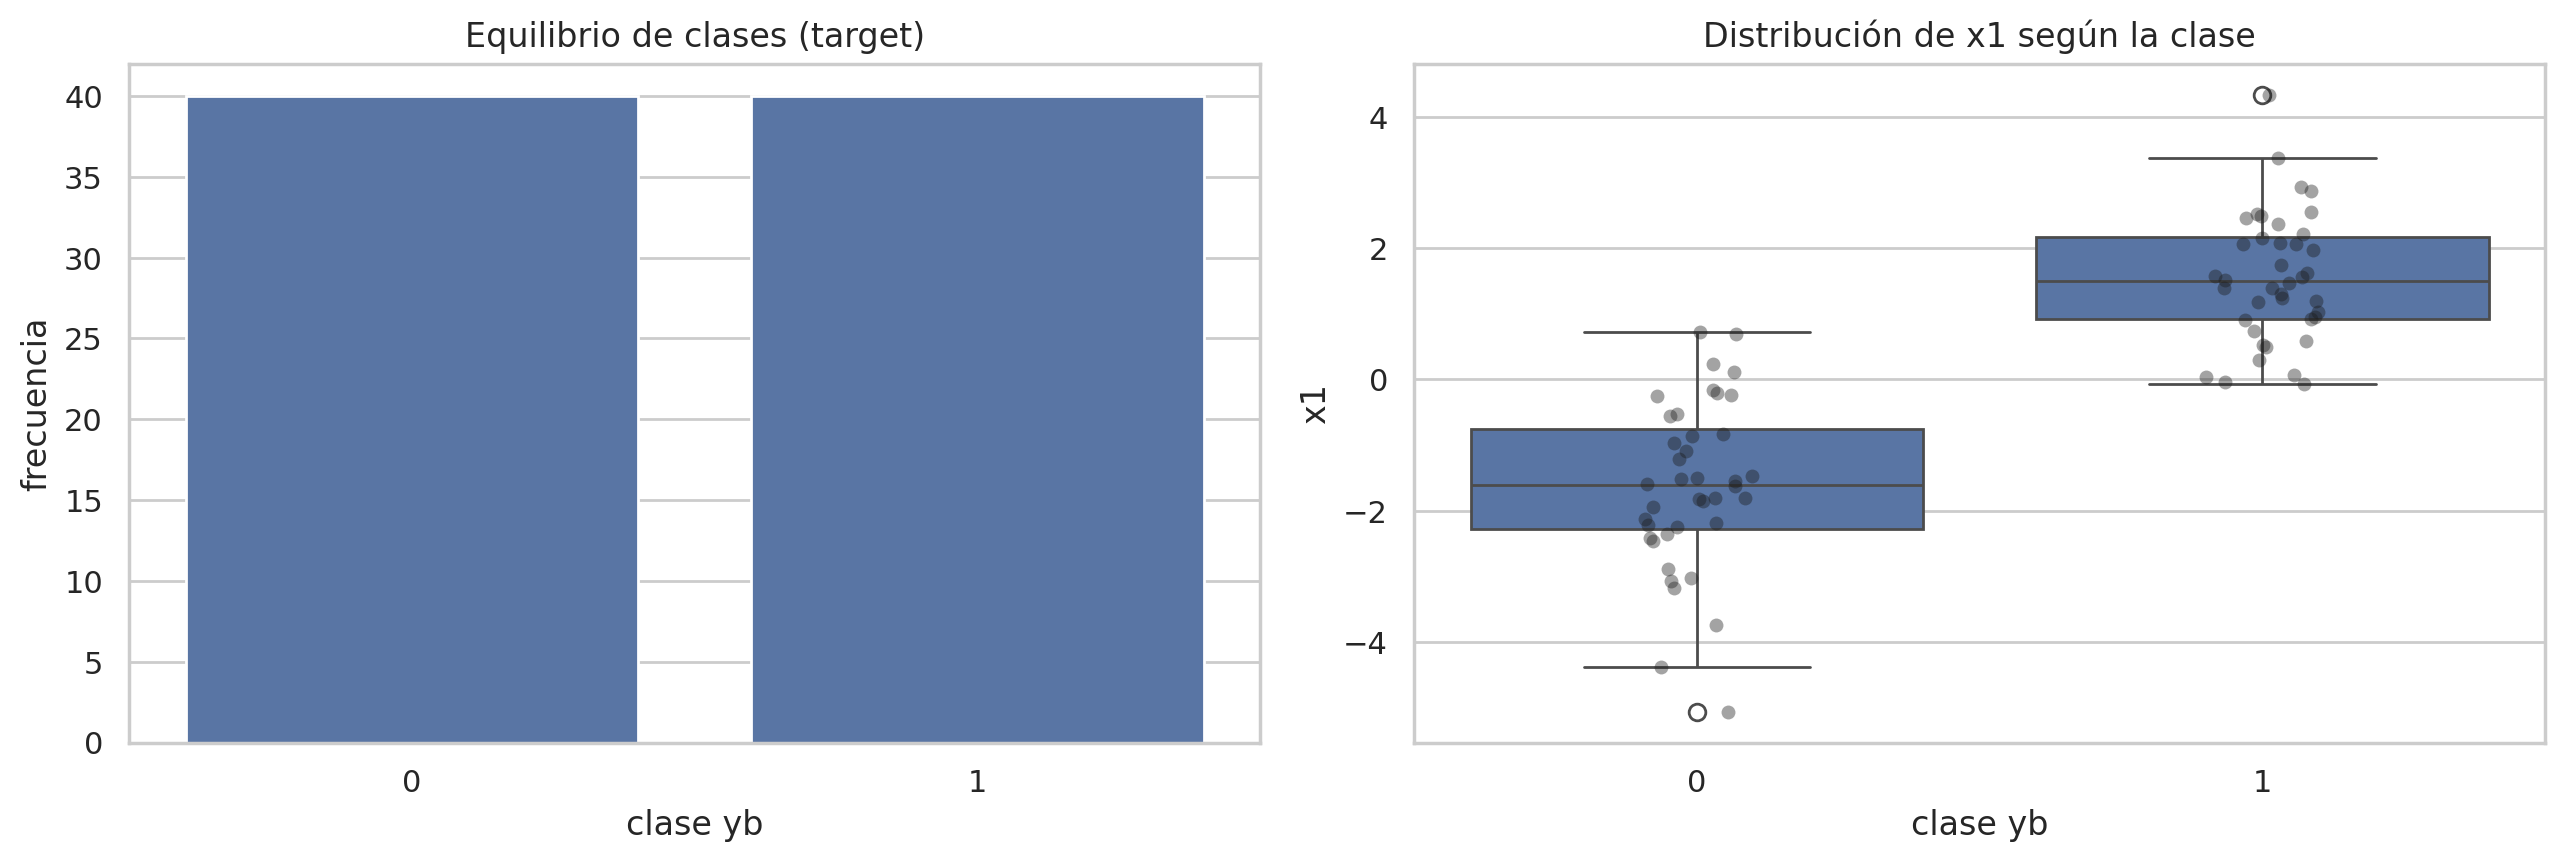

In [31]:
## Genración de datos artificiales
rng = np.random.RandomState(0)
x1 = np.r_[rng.normal(-2, 1.2, 40), rng.normal(2, 1.2, 40)]
yb = np.r_[np.zeros(40), np.ones(40)].astype(int)
toy = pd.DataFrame({'x1': x1, 'yb': yb})

## AED gráfico
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
# (a) equilibrio de clases
sns.countplot(x='yb', data=toy, ax=ax[0]); ax[0].set_title('Equilibrio de clases (target)')
ax[0].set_xlabel('clase yb'); ax[0].set_ylabel('frecuencia')
# (b) distribución de x1 por clase
sns.boxplot(x='yb', y='x1', data=toy, ax=ax[1])
sns.stripplot(x='yb', y='x1', data=toy, color='k', alpha=.4, ax=ax[1])
ax[1].set_title('Distribución de x1 según la clase')
ax[1].set_xlabel('clase yb'); ax[1].set_ylabel('x1')
plt.tight_layout()
plt.show()

El gráfico de barras confirma que las clases están **equilibradas** (40 y 40), así que la *accuracy* será una métrica fiable en este ejemplo. El diagrama de cajas muestra que `x1` **separa** bien las clases (la clase 0 toma valores bajos y la 1, altos), con una zona de **solapamiento** alrededor de 0 donde el modelo tendrá más incertidumbre. Es justo el escenario ideal para la regresión logística: una variable informativa con cierto solape.

Ahora entrenamos el modelo en **1D** y dibujamos la **curva de probabilidad** sobre los datos.

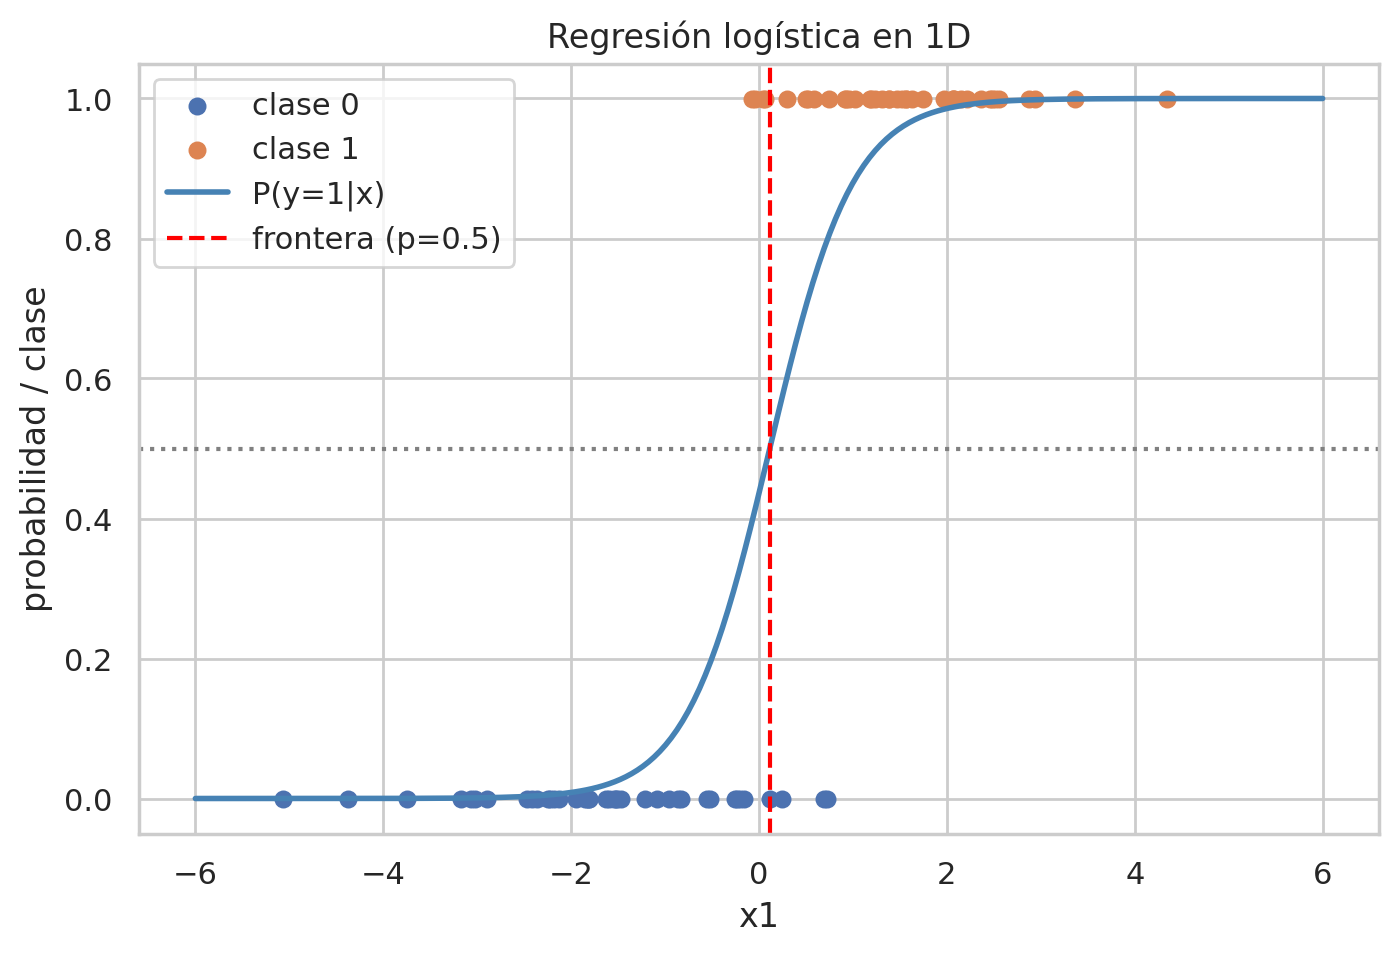

In [32]:
## Entrenamiento del modelo con todos los datos (GLM clásico)
lr1 = LogisticRegression().fit(x1.reshape(-1, 1), yb)
xs = np.linspace(-6, 6, 200).reshape(-1, 1)
# predicción de probabilidades
ps = lr1.predict_proba(xs)[:, 1]
# Punto de discriminación
x_umbral = -lr1.intercept_[0] / lr1.coef_[0, 0]      # donde p = 0.5
# Gráfico del modelo
plt.figure(figsize=(8, 5))
plt.scatter(x1[yb==0], yb[yb==0], s=30, label='clase 0')
plt.scatter(x1[yb==1], yb[yb==1], s=30, label='clase 1')
plt.plot(xs, ps, color='steelblue', lw=2, label='P(y=1|x)')
plt.axhline(0.5, color='gray', ls=':')
plt.axvline(x_umbral, color='red', ls='--', label='frontera (p=0.5)')
plt.xlabel('x1')
plt.ylabel('probabilidad / clase')
plt.legend()
plt.title('Regresión logística en 1D')
plt.show()

La curva azul es la probabilidad estimada: crece de 0 a 1 siguiendo la sigmoide, y la línea roja marca la **frontera** ($p=0.5$). A su derecha se predice clase 1 y a su izquierda clase 0. La pendiente de la S la fija el coeficiente: cuanto mayor, más "tajante" es el paso de una clase a otra.

**En 2D** la frontera de decisión es una **recta**. Coloreamos el plano por la probabilidad estimada y dibujamos la frontera $p=0.5$.

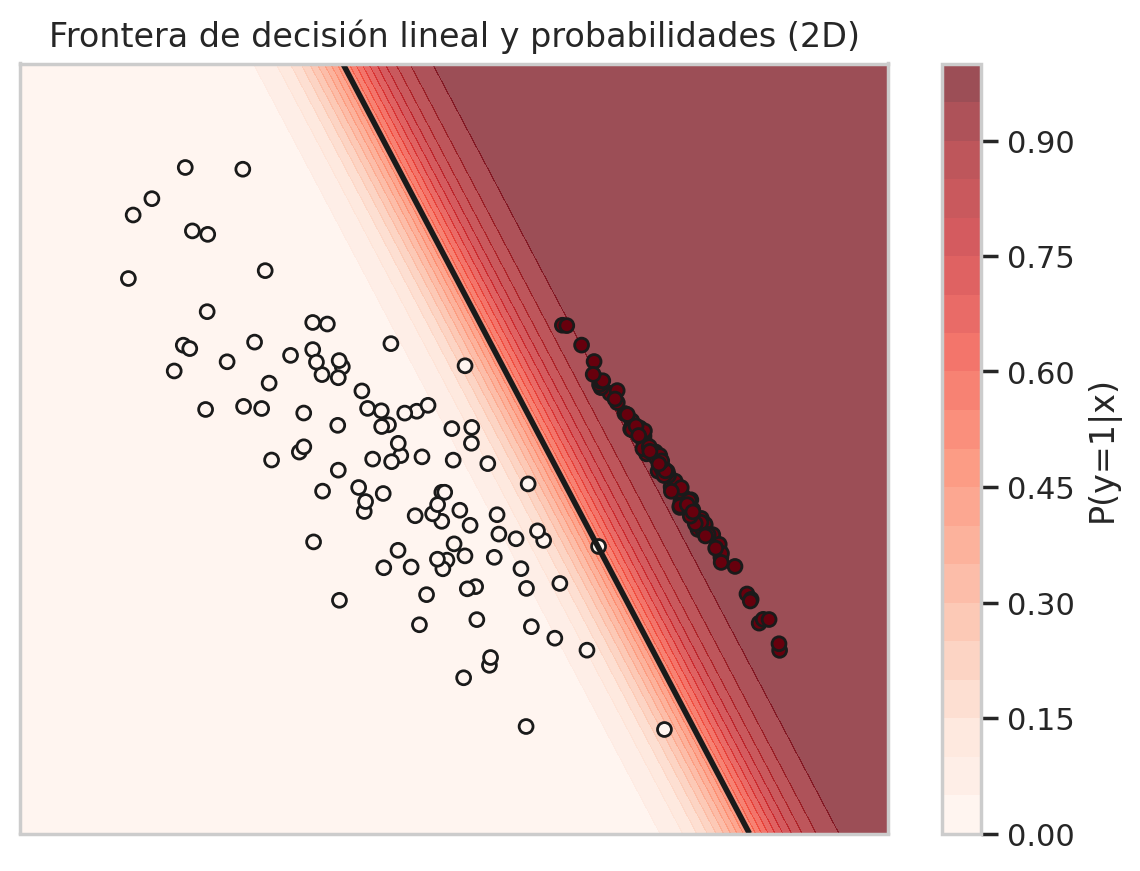

In [33]:
### Mapa de predicción y frontera de decisión
from sklearn.datasets import make_classification
# Generación de datos y predicción sobre el rango de las variables
X2, y2 = make_classification(n_samples=200, n_features=2, n_redundant=0, n_informative=2,
                             n_clusters_per_class=1, class_sep=1.2, random_state=4)
lr2 = LogisticRegression().fit(X2, y2)
xx, yy = np.meshgrid(np.linspace(X2[:,0].min()-1, X2[:,0].max()+1, 300),
                     np.linspace(X2[:,1].min()-1, X2[:,1].max()+1, 300))
Z = lr2.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
# mapa de predicción y frontera de decisión
plt.figure(figsize=(7, 5))
cf = plt.contourf(xx, yy, Z, levels=20, cmap='Reds', alpha=.7)
plt.colorbar(cf, label='P(y=1|x)')
plt.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
plt.scatter(X2[:,0], X2[:,1], c=y2, cmap='Reds', edgecolor='k', s=25)
plt.title('Frontera de decisión lineal y probabilidades (2D)')
plt.xticks([])
plt.yticks([])
plt.show()

El color es la probabilidad de clase 1 (rojo alto, blanco bajo) y la línea negra es la **frontera lineal** $p=0.5$. El gradiente perpendicular a la recta refleja que la probabilidad cambia más rápido en la dirección de $w$. Por muchas variables que tenga, un clasificador logístico siempre separa el espacio con un **hiperplano** como este.



# <font color="steelblue">7. Regresión logística en scikit-learn</font>

La clase es **`sklearn.linear_model.LogisticRegression`**, con los hiperparámetros descritos en la sección 4. Recordatorio de su interfaz: `fit(X, y)` estima los coeficientes; `predict`, `predict_proba` y `decision_function` devuelven clase, probabilidades y logit (sección 5); `coef_` e `intercept_` dan $w$ y $b$ (y $e^{w_j}$ los odds ratios). Conviene **estandarizar** las predictoras (lo hace `preprocesar_datos`): así la regularización trata a todas por igual y los odds ratios son comparables.






## <font color="steelblue">7.1. Parámetros del constructor</font>

**Optimización (cómo se ajusta).**
* **`solver`** `{'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}`, def. `'lbfgs'`
* **`tol`** `float`, def. `1e-4` — tolerancia: criterio de parada del optimizador.
* **`max_iter`** `int`, def. `100` — iteraciones máximas (súbelo si avisa de no convergencia).
* **`n_jobs`** `int`, def. `None` — núcleos para paralelizar (en el esquema uno-contra-resto). `-1` usa todos.
* **`verbose`** `int`, def. `0` — nivel de mensajes del solver.

**Datos, intercepto y clases.**
* **`fit_intercept`** `bool`, def. `True` — estima el término independiente $b$. `False` fuerza la frontera por el origen.
* **`class_weight`** `dict` o `'balanced'`, def. `None` — pesos por clase. **`'balanced'`** compensa el **desbalanceo** asignando peso inverso a la frecuencia de cada clase.
* **`random_state`** `int`, def. `None` — reproducibilidad (afecta a `sag`, `saga`, `liblinear`).
* **`multi_class`** *(heredado)* — en versiones antiguas elegía `'ovr'` (uno-contra-resto) vs `'multinomial'` vs `'auto'`. En las versiones **recientes está obsoleto/eliminado** y el comportamiento es automático (multinomial, salvo con `liblinear`); no lo uses en código nuevo.


## <font color="steelblue">7.2. Métodos principales</font>

* **`fit(X, y, sample_weight=None)`** — ajusta el modelo; `sample_weight` permite pesar muestras individuales.
* **`predict(X)`** — devuelve la **clase** predicha de cada muestra.
* **`predict_proba(X)`** — **probabilidades** de pertenencia a cada clase (sigmoide en binario, *softmax* en multiclase); filas que suman 1.
* **`predict_log_proba(X)`** — el logaritmo de esas probabilidades.
* **`decision_function(X)`** — el **logit** o puntuación lineal $w^\top x + b$ (distancia con signo a la frontera); en binario, el signo da la clase.
* **`score(X, y, sample_weight=None)`** — **exactitud** (*accuracy*) media sobre `(X, y)`.
* **`get_params()` / `set_params(**kwargs)`** — leer/fijar hiperparámetros (lo que usan `Pipeline` y `GridSearchCV`).
* **`densify()` / `sparsify()`** — convierte `coef_` a formato denso / disperso (gestión de memoria con muchas variables).

## <font color="steelblue">7.3. Atributos tras ajustar</font>

* **`coef_`** — matriz de **pesos** $w$: forma `(1, n_features)` en binario y `(n_clases, n_features)` en multiclase. $e^{w_j}$ son los **odds ratios**.
* **`intercept_`** — el **sesgo** $b$: `(1,)` en binario, `(n_clases,)` en multiclase.
* **`classes_`** — etiquetas de clase **ordenadas** (definen el orden de las columnas de `predict_proba` y de las filas de `coef_`).
* **`n_iter_`** — iteraciones que necesitó el solver hasta converger.
* **`n_features_in_`** — número de variables vistas en `fit`.
* **`feature_names_in_`** — nombres de las columnas si `X` era un `DataFrame` (útil para emparejar coeficientes con variables).

# <font color="steelblue">8. Aplicación: cáncer de mama (Breast Cancer Wisconsin)</font>

Clasificamos tumores como **malignos (0)** o **benignos (1)** a partir de 30 características de los núcleos celulares.

In [34]:
from sklearn.datasets import load_breast_cancer
breast_cancer = pd.concat([load_breast_cancer(as_frame=True).data,
                           load_breast_cancer(as_frame=True).target], axis=1)
breast_cancer['target'] = breast_cancer['target'].astype('category')
print('Dimensiones:', breast_cancer.shape)

Dimensiones: (569, 31)


## <font color="steelblue">8.1. Análisis descriptivo del target y de las predictoras</font>

Antes de modelar conviene mirar los datos. Primero el **equilibrio del target** (¿hay muchas más muestras de una clase?) y después **cómo se comporta cada predictora respecto a la clase** (qué variables separan mejor benignos de malignos).

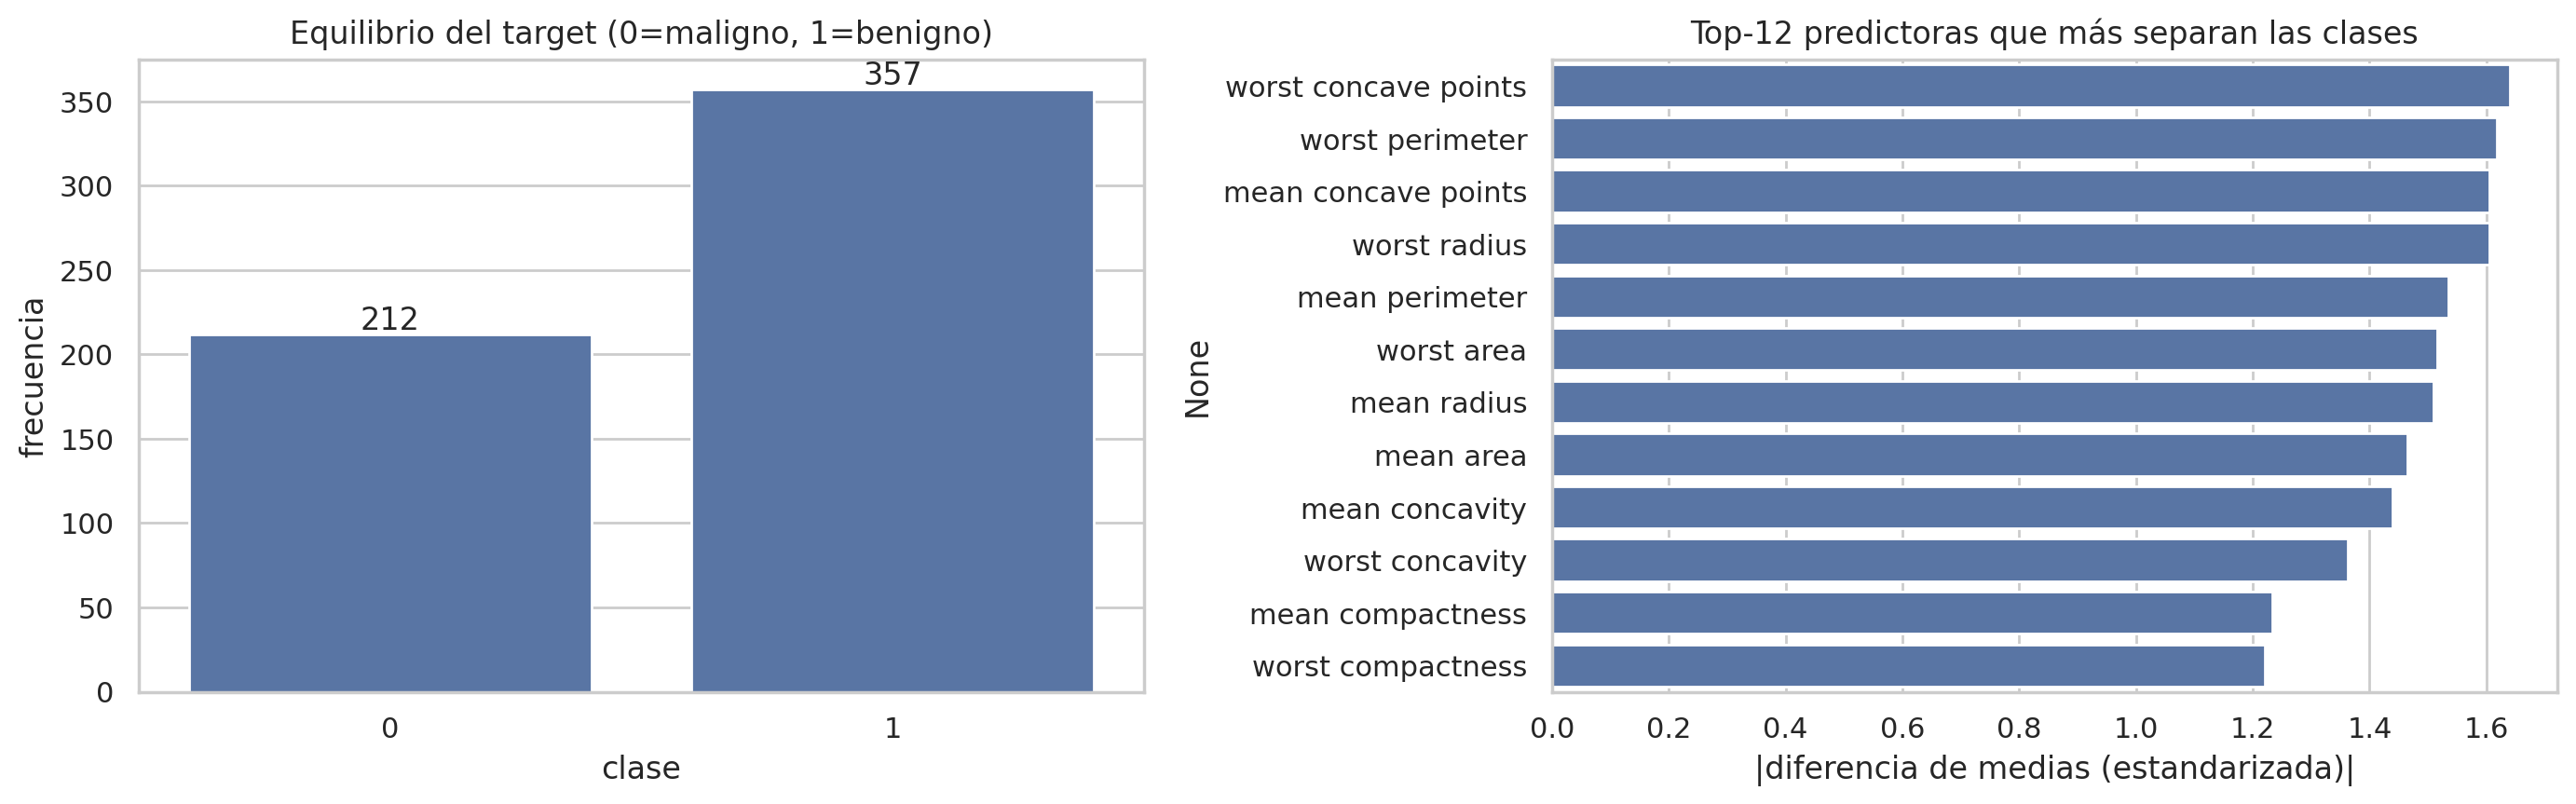

Proporción de cada clase:
target
1    0.627
0    0.373


In [35]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
# (a) equilibrio del target
conteo = breast_cancer['target'].value_counts().sort_index()
sns.barplot(x=conteo.index.astype(str), y=conteo.values, ax=ax[0])
for i, v in enumerate(conteo.values): ax[0].text(i, v+3, str(v), ha='center')
ax[0].set_title('Equilibrio del target (0=maligno, 1=benigno)')
ax[0].set_xlabel('clase'); ax[0].set_ylabel('frecuencia')

# (b) poder de separación de cada predictora: |diferencia de medias estandarizadas|
Xnum = breast_cancer.drop('target', axis=1)
Xz = (Xnum - Xnum.mean()) / Xnum.std()
sep = (Xz[breast_cancer['target']==1].mean() - Xz[breast_cancer['target']==0].mean()).abs().sort_values(ascending=False)
sns.barplot(x=sep.values[:12], y=sep.index[:12], ax=ax[1])
ax[1].set_title('Top-12 predictoras que más separan las clases')
ax[1].set_xlabel('|diferencia de medias (estandarizada)|')
plt.tight_layout()
plt.show()

print('Proporción de cada clase:')
print((breast_cancer['target'].value_counts(normalize=True).round(3)).to_string())

El target está moderadamente desequilibrado: ~63 % de tumores benignos frente a ~37 % malignos. No es un desbalanceo extremo, pero desaconseja usar la *accuracy* como única métrica (un modelo que dijera "benigno" siempre acertaría el 63 %). El segundo gráfico muestra que variables relacionadas con el tamaño y la forma del núcleo (*worst concave points*, *worst perimeter*, *worst radius*, *mean concave points*…) son las que más separan las clases: tumores malignos tienden a núcleos mayores y más irregulares. Lo confirmamos con diagramas de caja de las cuatro más separadoras.

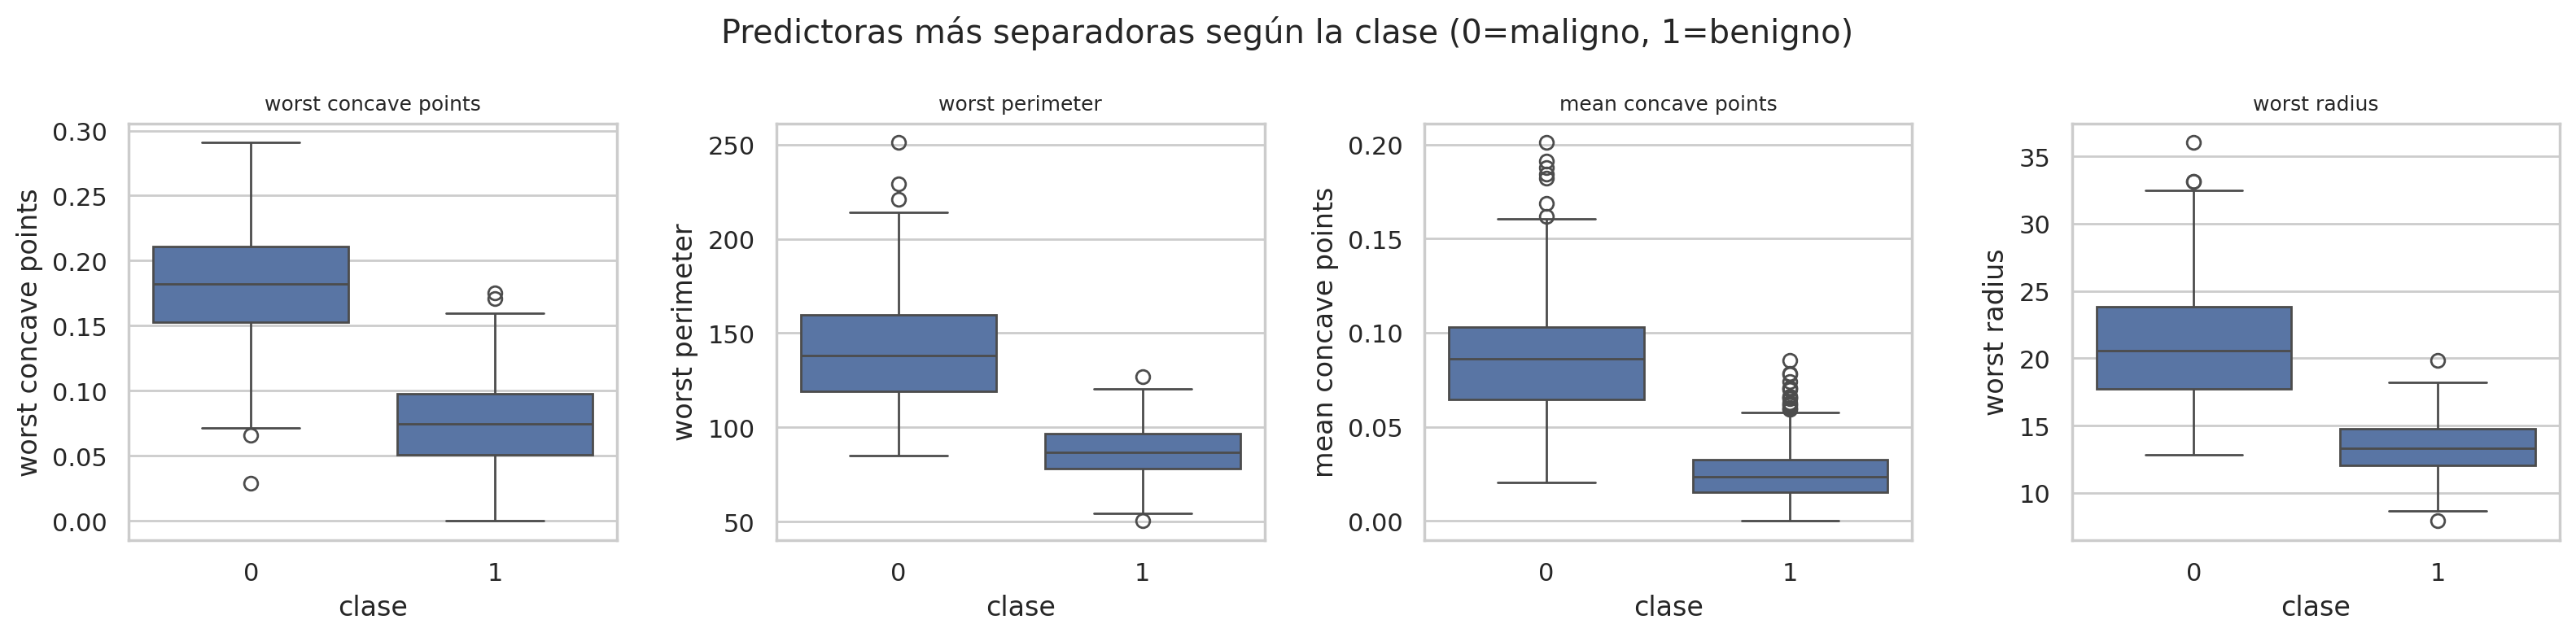

In [36]:
top4 = sep.index[:4]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for a, var in zip(axes, top4):
    sns.boxplot(x='target', y=var, data=breast_cancer, ax=a)
    a.set_title(var, fontsize=9)
    a.set_xlabel('clase')
plt.suptitle('Predictoras más separadoras según la clase (0=maligno, 1=benigno)')
plt.tight_layout()
plt.show()

En las cuatro variables, las cajas de malignos (0) y benignos (1) están **claramente desplazadas** y apenas se solapan: valores altos se asocian a tumores **malignos**. Esto anticipa que el problema es **bastante separable** y que un modelo lineal como la regresión logística debería funcionar muy bien.



## <font color="steelblue">8.2. Preprocesado y división de muestras</font>

Dividimos primero en entrenamiento/test (estratificando por el target) y **después** preprocesamos: ajustamos el preprocesador **solo con el entrenamiento** y lo aplicamos al test (evitando fuga de información).

In [37]:
strain_raw, stest_raw = split_sample(breast_cancer, 'target', 0.2, 123, True)
strain, prep = preprocesar_datos(strain_raw, 'target')
stest,  _    = preprocesar_datos(stest_raw,  'target', prep)
xtrain, ytrain = strain.drop('target', axis=1), strain['target']
xtest,  ytest  = stest.drop('target', axis=1),  stest['target']
print('Entrenamiento:', xtrain.shape, '| Test:', xtest.shape)

Estratificando por 'target'.
  Entrenamiento: 455 muestras | Test: 114 muestras
Entrenamiento: (455, 30) | Test: (114, 30)


## <font color="steelblue">8.3. Modelo base y odds ratios</font>

Obtenemos un gráfico de lso odds ratio del modelo entrenado.

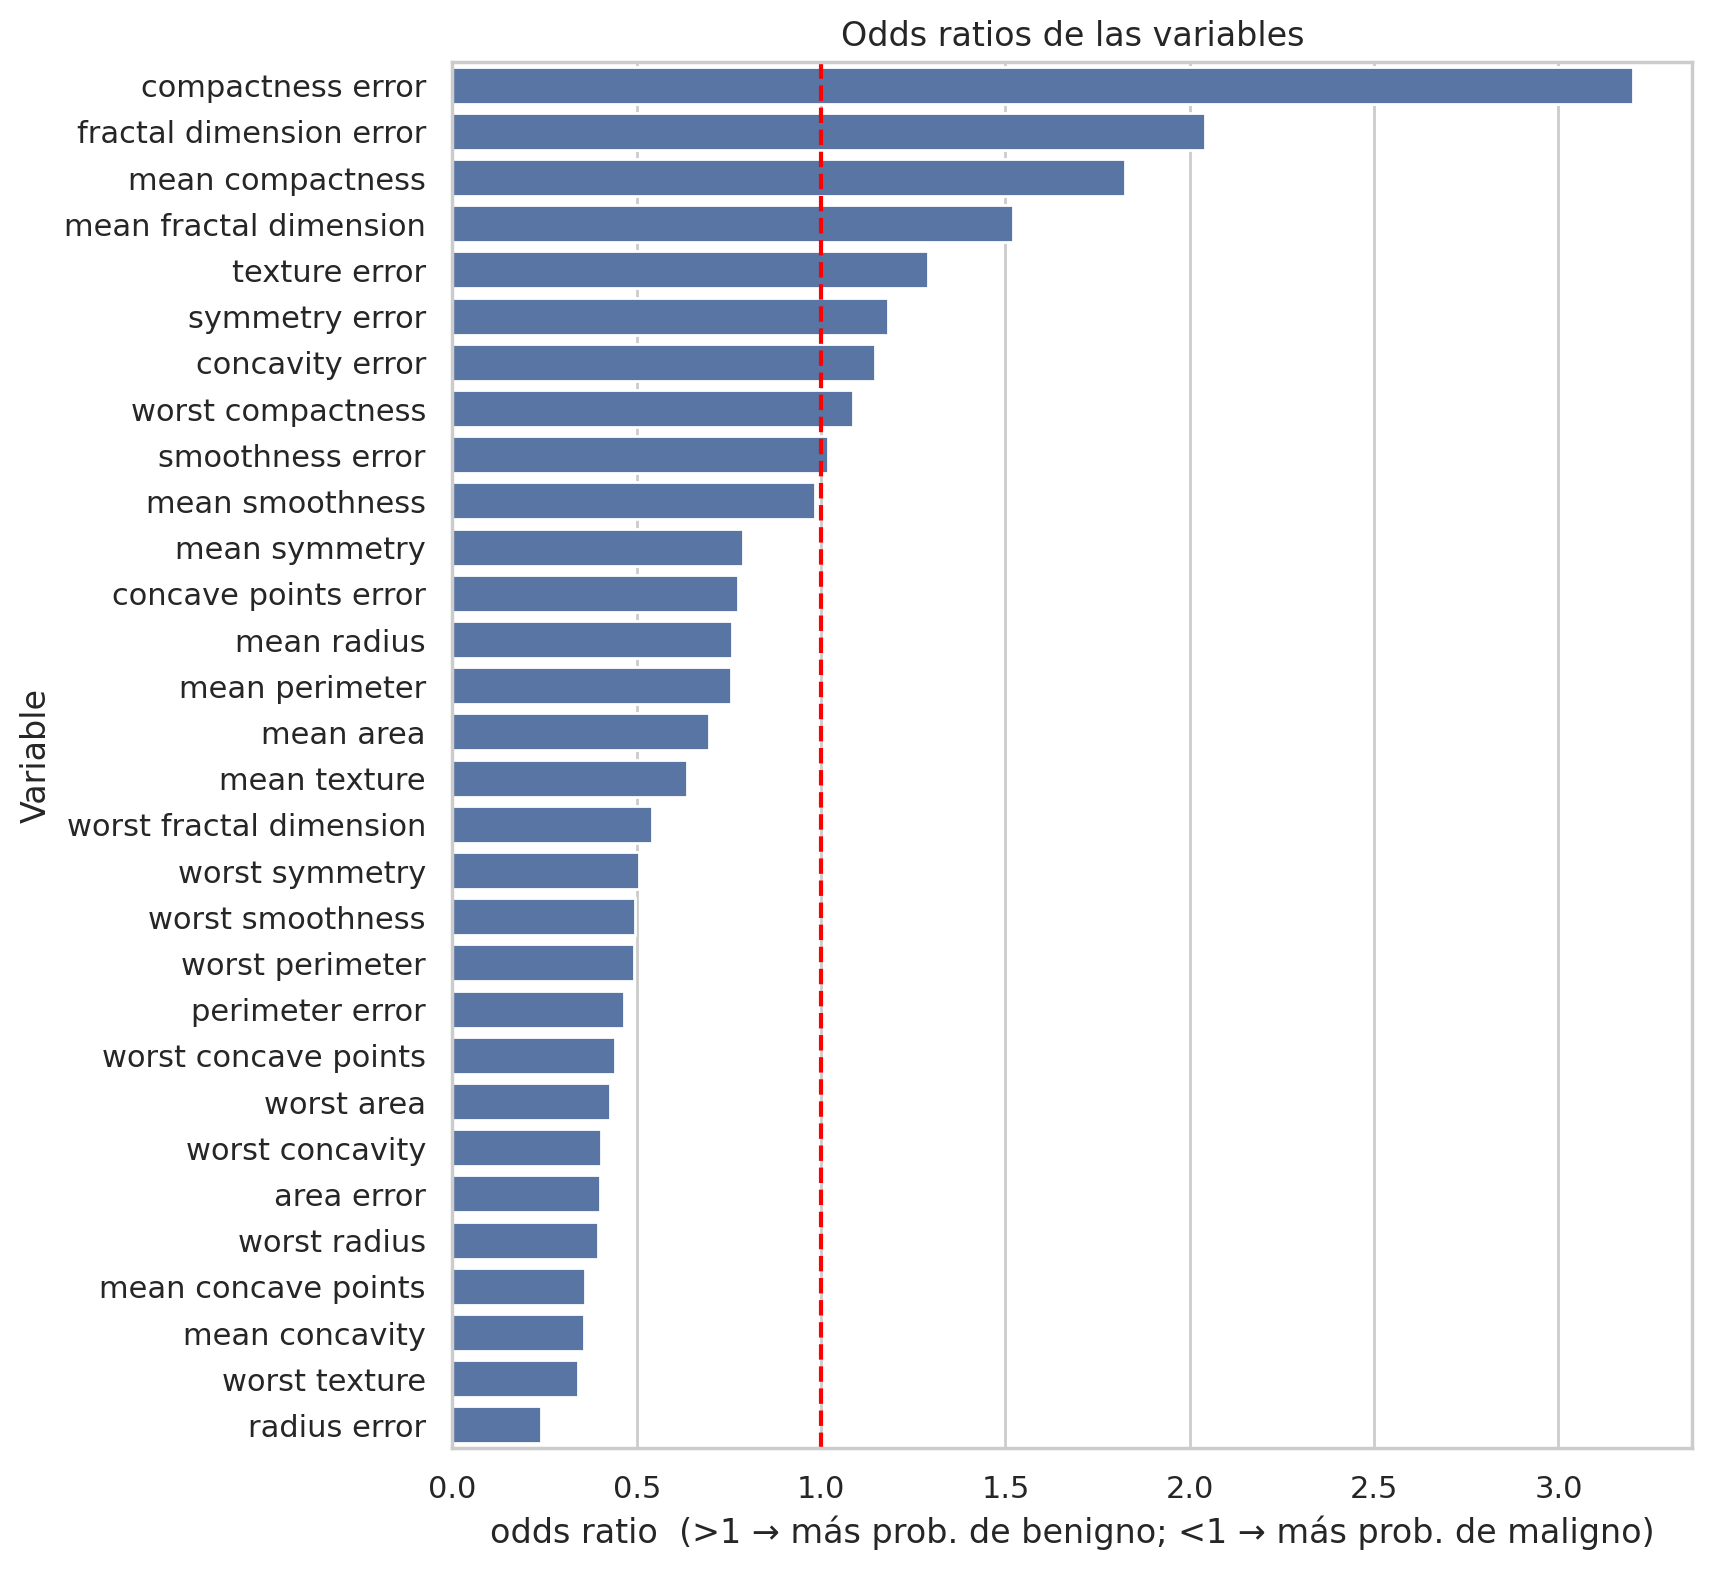

,Variable,Coeficiente,odds
15,compactness error,1.164125,3.203120
19,fractal dimension error,0.713135,2.040379
5,mean compactness,0.601734,1.825282


In [38]:
modelo = LogisticRegression(max_iter=5000).fit(xtrain, ytrain)
coef_df = pd.DataFrame({'Variable': xtrain.columns, 'Coeficiente': modelo.coef_.flatten()})
coef_df['odds'] = np.exp(coef_df['Coeficiente'])
coef_df = coef_df.sort_values('odds', ascending=False)

fig = plt.figure(figsize=(8, 9))
sns.barplot(data=coef_df, x='odds', y='Variable')
plt.axvline(1, color='red', ls='--')
plt.xlabel('odds ratio  (>1 → más prob. de benigno; <1 → más prob. de maligno)')
plt.title('Odds ratios de las variables')
plt.show()
coef_df.head(3)

Recordemos que la clase positiva es **1 = benigno**, así que un $\text{OR}>1$ empuja hacia *benigno* y un $\text{OR}<1$ hacia *maligno*. Las variables con odds ratio muy por encima de 1 (barras a la derecha de la línea roja) aumentan la probabilidad de que el tumor sea benigno por cada unidad (estandarizada) que crecen; las de odds muy por debajo de 1 (a la izquierda) son factores de riesgo de malignidad: cuanto mayores, más probable que el tumor sea maligno —y suelen coincidir con las variables de tamaño/irregularidad que vimos en el descriptivo—. Las barras cercanas a 1 corresponden a variables con poco efecto propio (a menudo por estar correlacionadas con otras). Como las predictoras están estandarizadas, la distancia de cada barra a 1 mide la importancia relativa de esa variable en el modelo.



## <font color="steelblue">8.4. Evaluación y validación del modelo</font>

Justificamos primero la métrica: dado el desbalanceo moderado (63/37) y, sobre todo, que el error grave es clasificar un tumor maligno como benigno (un falso negativo con coste clínico), no nos basta la *accuracy*. Usamos el F1 (media armónica de *precision* y *recall*), que penaliza tanto las falsas alarmas como los positivos no detectados y es robusto al desbalanceo. Analizamos cada herramienta por separado y damos una valoración global. Utilizamos diferentes funciones que nos serán de utilidad en todos los modelos de clasificación. Antes de ver el resultado sobre el banco de datos presentamos la ayuda de dicho función.

In [39]:
help(reports_clas)

Help on function reports_clas in module auto_ML:

reports_clas(modelo, xtrain, ytrain, xtest, ytest, labels=None)
    Función para obtener el report de clasificación para un modelo de clasificación. Proporciona los resultados para la muestra de entrenamiento y test

    Argumentos:
    - modelo: modelo entrenado
    - xtrain: inputs de entrenamiento
    - ytrain: target de entrenamiento
    - xtest: inputs de test
    - ytest: target de test

    Return
     - reporte de clasificación para muestra de entrenamiento y test



**(a) Informe de clasificación.** Da *precision*, *recall* y *f1* por clase en entrenamiento y test. Lo relevante es que las métricas de **test** sean altas y **parecidas** a las de entrenamiento: si lo son, el modelo **no sobreajusta**. En este caso el f1 de test ronda **0.97**, casi idéntico al de entrenamiento.

In [40]:
reports_clas(modelo, xtrain, ytrain, xtest, ytest)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       170
           1       0.98      1.00      0.99       285

    accuracy                           0.99       455
   macro avg       0.99      0.99      0.99       455
weighted avg       0.99      0.99      0.99       455


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        42
           1       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



Antes de presentar los resulatdos mostramos la ayuda de la función que utilizaremos para esta tarea.

In [41]:
help(matriz_confusion)

Help on function matriz_confusion in module auto_ML:

matriz_confusion(modelo, xtest, ytest, labels=None)
    Matriz de confusión de un modelo de clasificación en % de acierto dentro de cada
    clase real (normalizada por fila). Robusta a clases sin muestras (evita /0).

    Argumentos: modelo entrenado, xtest, ytest. Return: matriz normalizada (np.array).
       - labels: Lista de etiquetas para el classification_report y la matriz de confusión.
                Si es None, se usarán las etiquetas por defecto de classification_report.



**(b) Matriz de confusión (interpretación detallada).** La matriz está **normalizada por fila** (cada fila es una clase real y suma 100 %). Sobre el test:

* **Fila "maligno" (clase 0):** el modelo clasifica correctamente como malignos **≈95 %** de los tumores que realmente lo son, y deja escapar **≈5 %** (los etiqueta como benignos). En frecuencias absolutas son **40 aciertos y 2 fallos** de 42 malignos. Esos 2 casos son **falsos negativos**: el error **más peligroso** en este problema, porque a un paciente con tumor maligno se le diría que es benigno.
* **Fila "benigno" (clase 1):** clasifica bien **≈99 %** de los benignos (**71 de 72**), con un único **falso positivo** (un benigno marcado como maligno), error mucho menos grave (conllevaría pruebas adicionales, no un diagnóstico perdido).

La lectura clave es que el modelo es **muy preciso en ambas clases**, pero los pocos errores que comete se reparten de forma asimétrica en cuanto a **gravedad**. Si en la práctica clínica quisiéramos **reducir los falsos negativos**, podríamos **bajar el umbral** de decisión (sección 5): ganaríamos *recall* en la clase maligna a costa de algún falso positivo más. La matriz de confusión es, por tanto, la herramienta que conecta las métricas con el **coste real** de cada tipo de error.

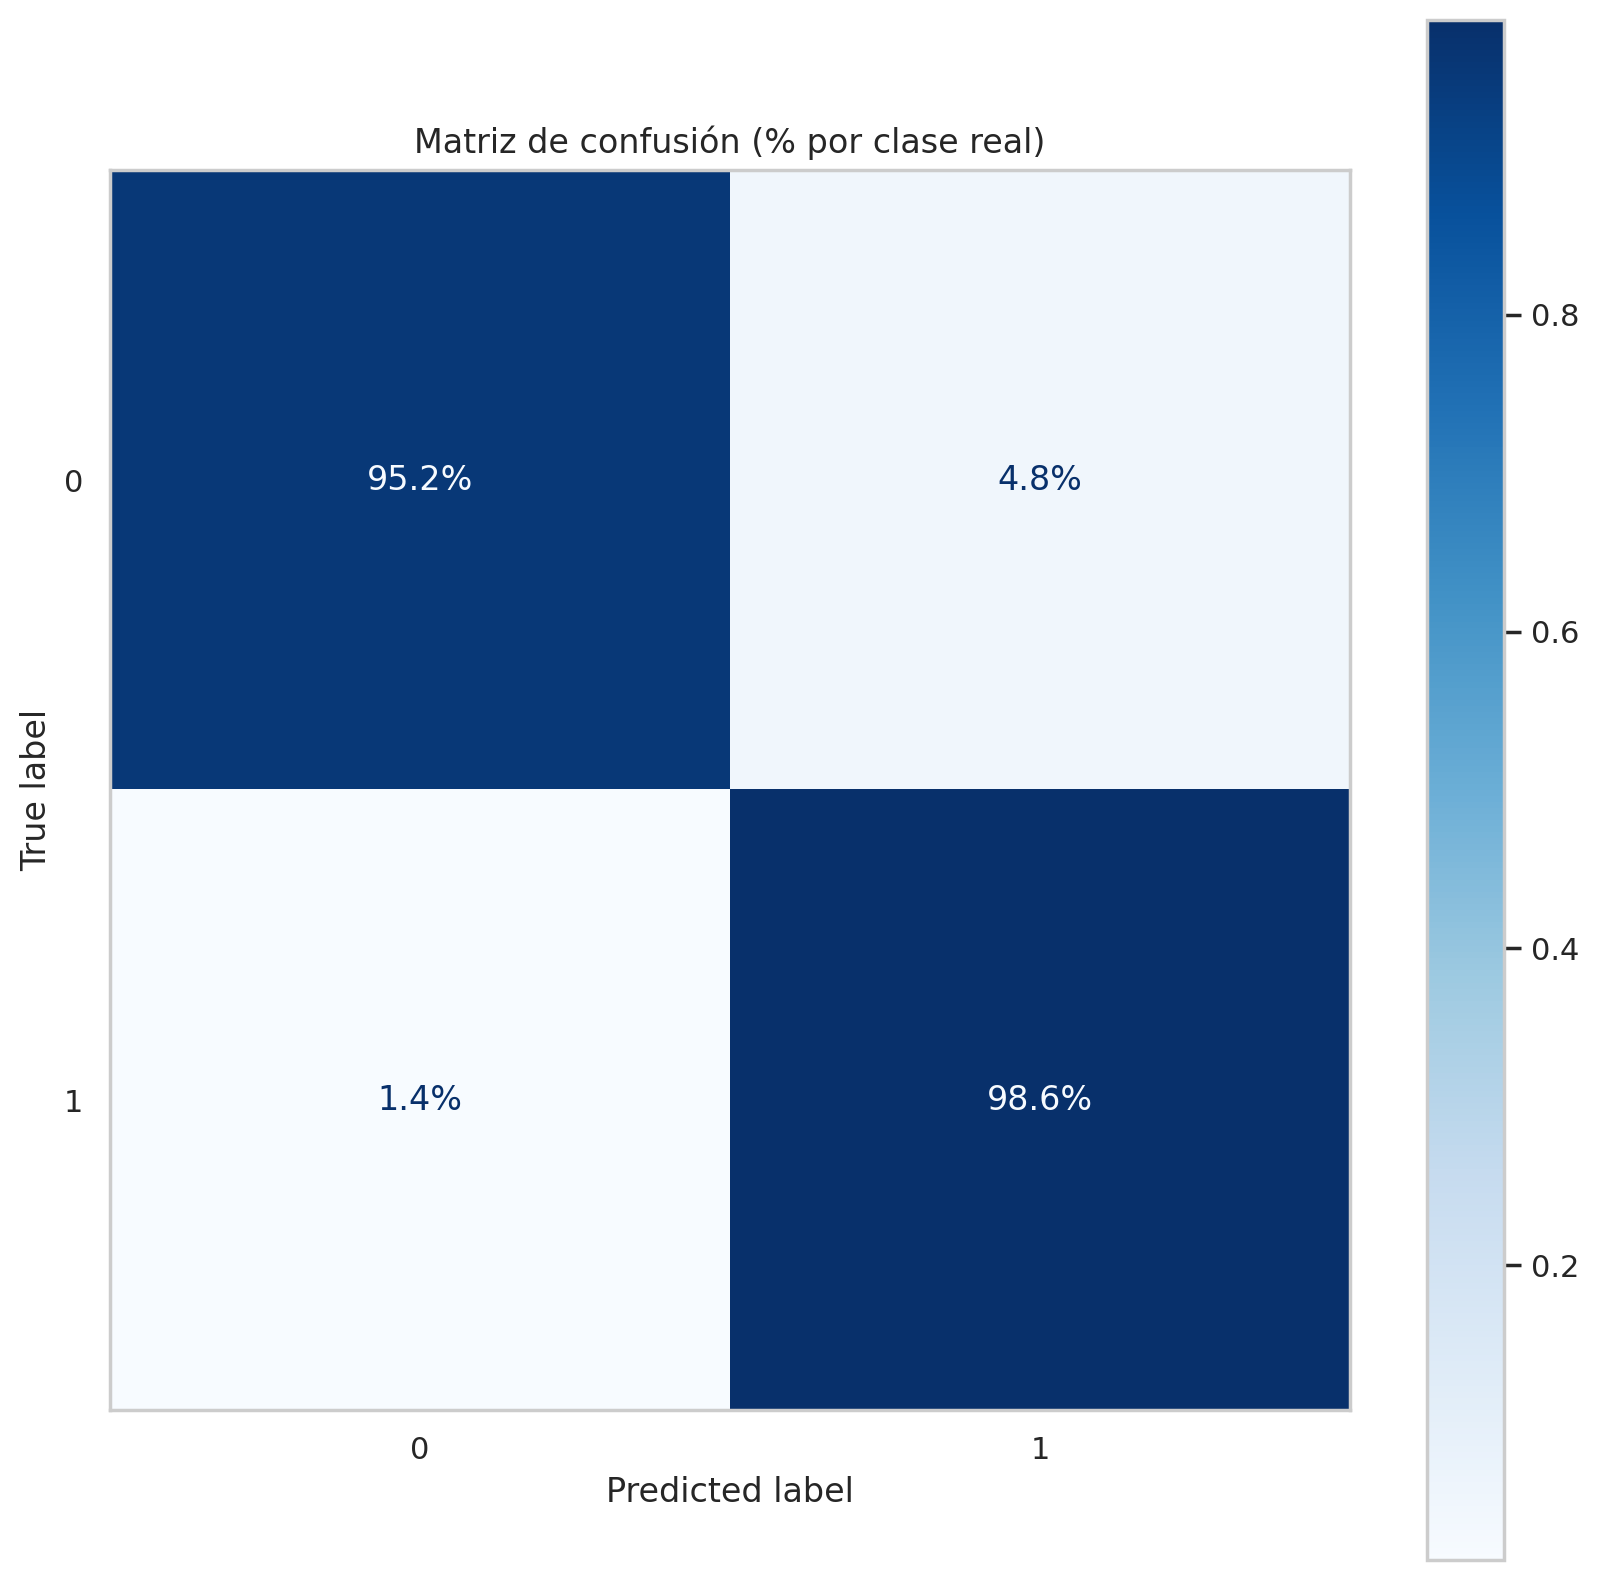

In [42]:
cm = matriz_confusion(modelo, xtest, ytest);

Ahora presetamos la función para la validaciónd el modelo:

In [43]:
help(validar_modelo)

Help on function validar_modelo in module auto_ML:

validar_modelo(modelo, X, y, metric='accuracy', folds=5)
    Valida un modelo de clasificación usando validación cruzada estratificada.

    Parámetros
    ----------
    modelo : object
        Clasificador de scikit-learn.
    X : pandas.DataFrame o numpy.ndarray
        Características de entrada.
    y : pandas.Series o numpy.ndarray
        Variable objetivo.
    metric : str, optional
        Métrica de evaluación ('accuracy', 'precision', 'recall', 'f1', 'balanced_accuracy', 'roc_auc').
        Por defecto es 'accuracy'.
    folds : int, optional
        Número de folds para la validación cruzada. Por defecto es 5.

    Returns
    -------
    pandas.DataFrame
        DataFrame con los resultados de la validación cruzada por fold.



**(c) Validación cruzada.** Repitimos el ajuste en 10 particiones distintas y reportamos el f1 **medio ± desviación**. Un f1 medio alto (~0.97) con **desviación pequeña** indica que el rendimiento **no depende** de la partición concreta: la solución es **estable y reproducible**, no fruto de una división de datos afortunada.

In [44]:
val = validar_modelo(modelo, xtrain, ytrain, 'f1', 10)

Validacion cruzada (10 folds, score=f1): media = 0.988 +/- 0.011


Para finalizar presentamos la función que automatiza la obtención de la curva de aprendizaje.

In [45]:
help(curva_aprendizaje)

Help on function curva_aprendizaje in module auto_ML:

curva_aprendizaje(modelo, X, y, score='r2', folds=5)
    Genera una curva de aprendizaje para modelos de regresión.
    Muestra cómo evoluciona la métrica de validación al aumentar el tamaño del set de entrenamiento.



**(d) Curva de aprendizaje.** Muestra el f1 en **entrenamiento** (azul) y **validación** (rojo) según crece el nº de muestras. Su comportamiento aquí es el de un modelo **sano**: la curva de entrenamiento parte muy alta y la de validación **sube** al añadir datos hasta **converger** con ella, quedando ambas **altas y juntas** con una **brecha pequeña**. Eso indica **poco sobreajuste** (la brecha no es grande) y **poco sesgo** (el nivel es alto): el modelo tiene la complejidad adecuada y **no necesitaría muchos más datos** para mejorar. Si la brecha fuese grande, sospecharíamos sobreajuste; si ambas curvas quedasen bajas, infraajuste.

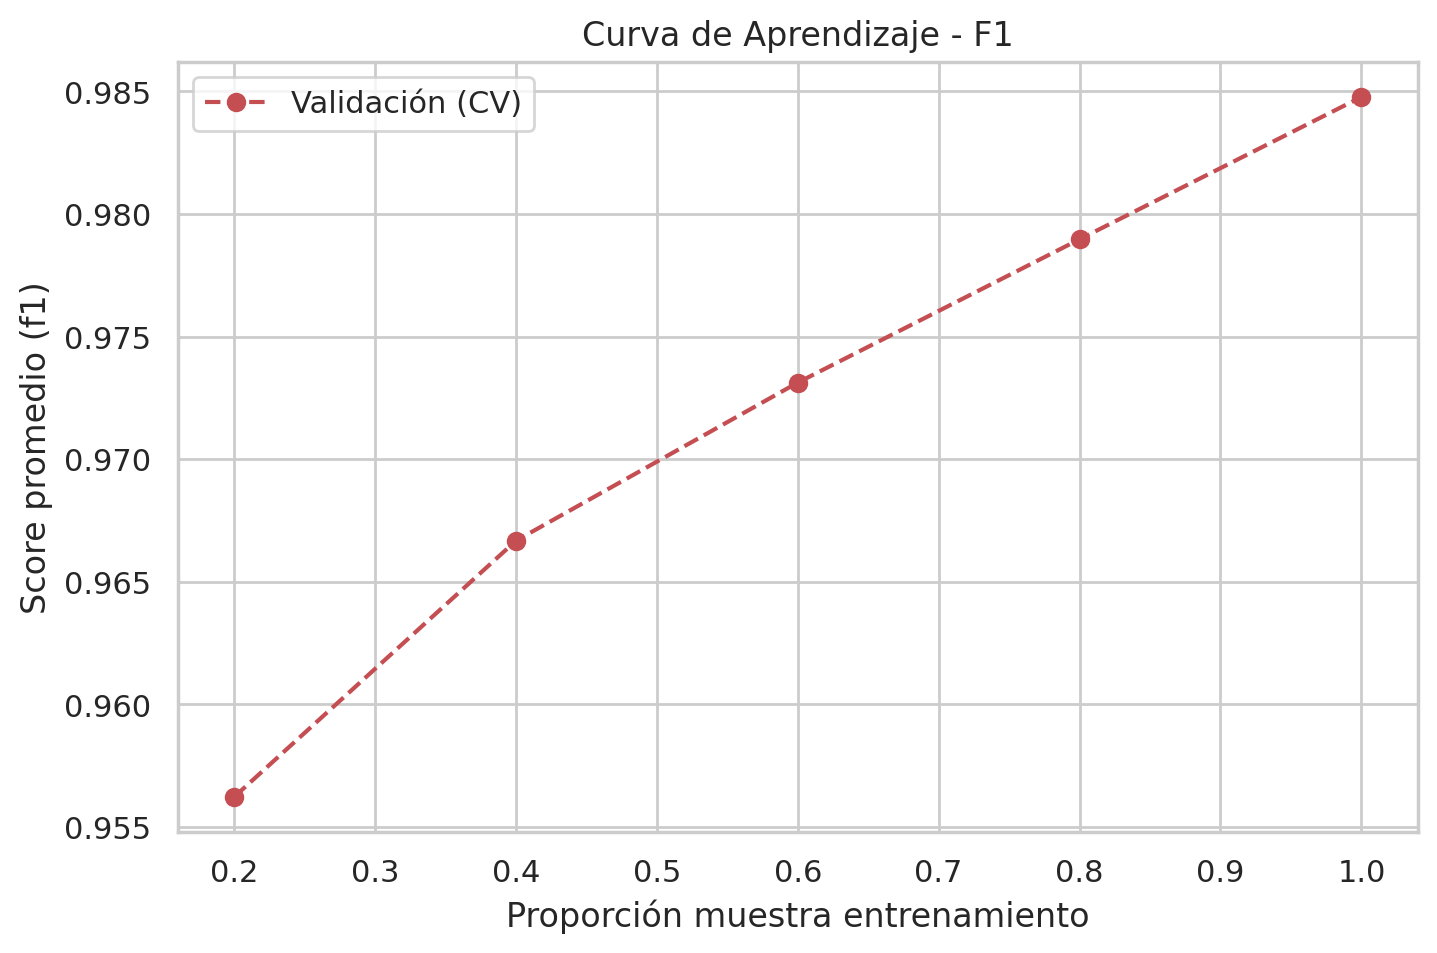

In [46]:
datos_pp, _ = preprocesar_datos(breast_cancer, 'target')
X = datos_pp.drop('target', axis=1)
y = datos_pp['target']
curva_aprendizaje(modelo, X, y, 'f1', 10);

**Valoración global.** El informe, la matriz de confusión, la validación cruzada y la curva de aprendizaje son **coherentes** entre sí: un modelo lineal sencillo alcanza un F1 ≈ 0.97 **estable** y **generaliza bien**, con errores escasos pero que conviene vigilar por su coste clínico (los falsos negativos). Es un excelente punto de partida; veamos si se puede **simplificar** sin perder calidad.





## <font color="steelblue">8.5. Selección de características</font>

La **eliminación recursiva (RFE)** busca el subconjunto de variables que maximiza el f1 por validación cruzada (sin fuga, gracias a la versión corregida).

Calculando el ranking global de variables (puede tardar un momento)...
Evaluando combinaciones optimizando por: F1...

k óptimo: 20  |  f1: 0.9868


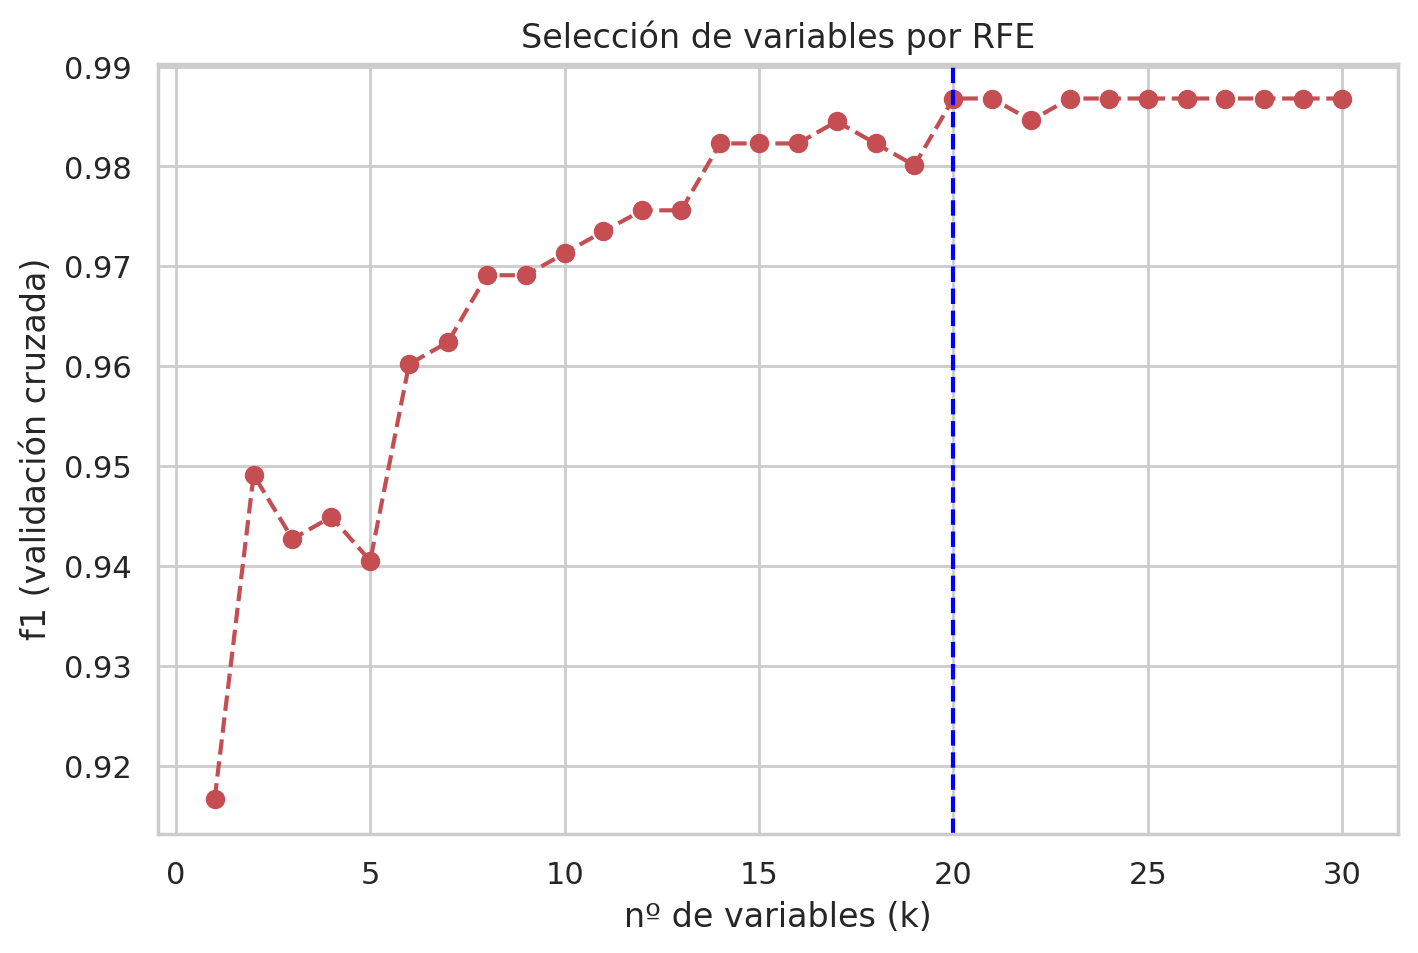

,k,accuracy,f1,recall,Nueva Variable
0,1,0.9187,0.9167,0.9187,worst area
1,2,0.9495,0.9491,0.9495,worst concave points
2,3,0.9429,0.9427,0.9429,worst radius
3,4,0.9451,0.9449,0.9451,radius error
4,5,0.9407,0.9405,0.9407,worst concavity
5,6,0.9604,0.9602,0.9604,compactness error
6,7,0.9626,0.9624,0.9626,mean concave points
7,8,0.9692,0.9691,0.9692,worst texture
8,9,0.9692,0.9691,0.9692,worst perimeter
9,10,0.9714,0.9713,0.9714,area error


In [50]:
scores_df, variables, k_best, score_best = select_variables(
    LogisticRegression(max_iter=5000), xtrain, ytrain, range(1, xtrain.shape[1]+1), 'f1', cv=5)

print(f"k óptimo: {k_best}  |  f1: {score_best:.4f}")
plt.figure(figsize=(8, 5))
plt.plot(scores_df.k, scores_df.f1, 'o--', color='r')
plt.axvline(k_best, color='blue', ls='--')
plt.xlabel('nº de variables (k)')
plt.ylabel('f1 (validación cruzada)')
plt.title('Selección de variables por RFE')
plt.grid(True)
plt.show()
scores_df.round(4)

**Interpretación: hacia un modelo más parsimonioso.** Lo importante no es solo el *k* óptimo, sino el **rango de valores del f1**: la curva **sube muy rápido** y se **aplana** enseguida. A partir de unas **10–13 variables** el f1 ya es ≈ **0.97**, prácticamente el mismo que con las **30** (≈ 0.98); la diferencia está en la **tercera cifra decimal**. Por tanto, aunque el máximo se alcance con muchas variables, una **solución con ~13 predictoras** es preferible en la práctica: rinde casi igual y es **más simple, más rápida y más interpretable** (principio de parsimonia). Conviene elegir el *k* a partir del cual la curva **deja de mejorar de forma apreciable**, no necesariamente el máximo absoluto.

### <font color="steelblue">8.5.1. Modelo con las 13 predictoras más relevantes</font>

Construimos explícitamente ese modelo parsimonioso: seleccionamos con RFE las **13 variables más relevantes** (sobre el entrenamiento), entrenamos sobre ellas y lo **evaluamos** (matriz de confusión y validación) para compararlo con el de 30 variables.

In [51]:
sel13 = RFE(LogisticRegression(max_iter=5000), n_features_to_select=13).fit(xtrain, ytrain)
vars13 = xtrain.columns[sel13.support_].tolist()
print('13 predictoras seleccionadas:')
print(vars13)
modelo13 = LogisticRegression(max_iter=5000).fit(xtrain[vars13], ytrain)

13 predictoras seleccionadas:
['mean concavity', 'mean concave points', 'radius error', 'perimeter error', 'area error', 'compactness error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst concavity', 'worst concave points', 'worst symmetry']


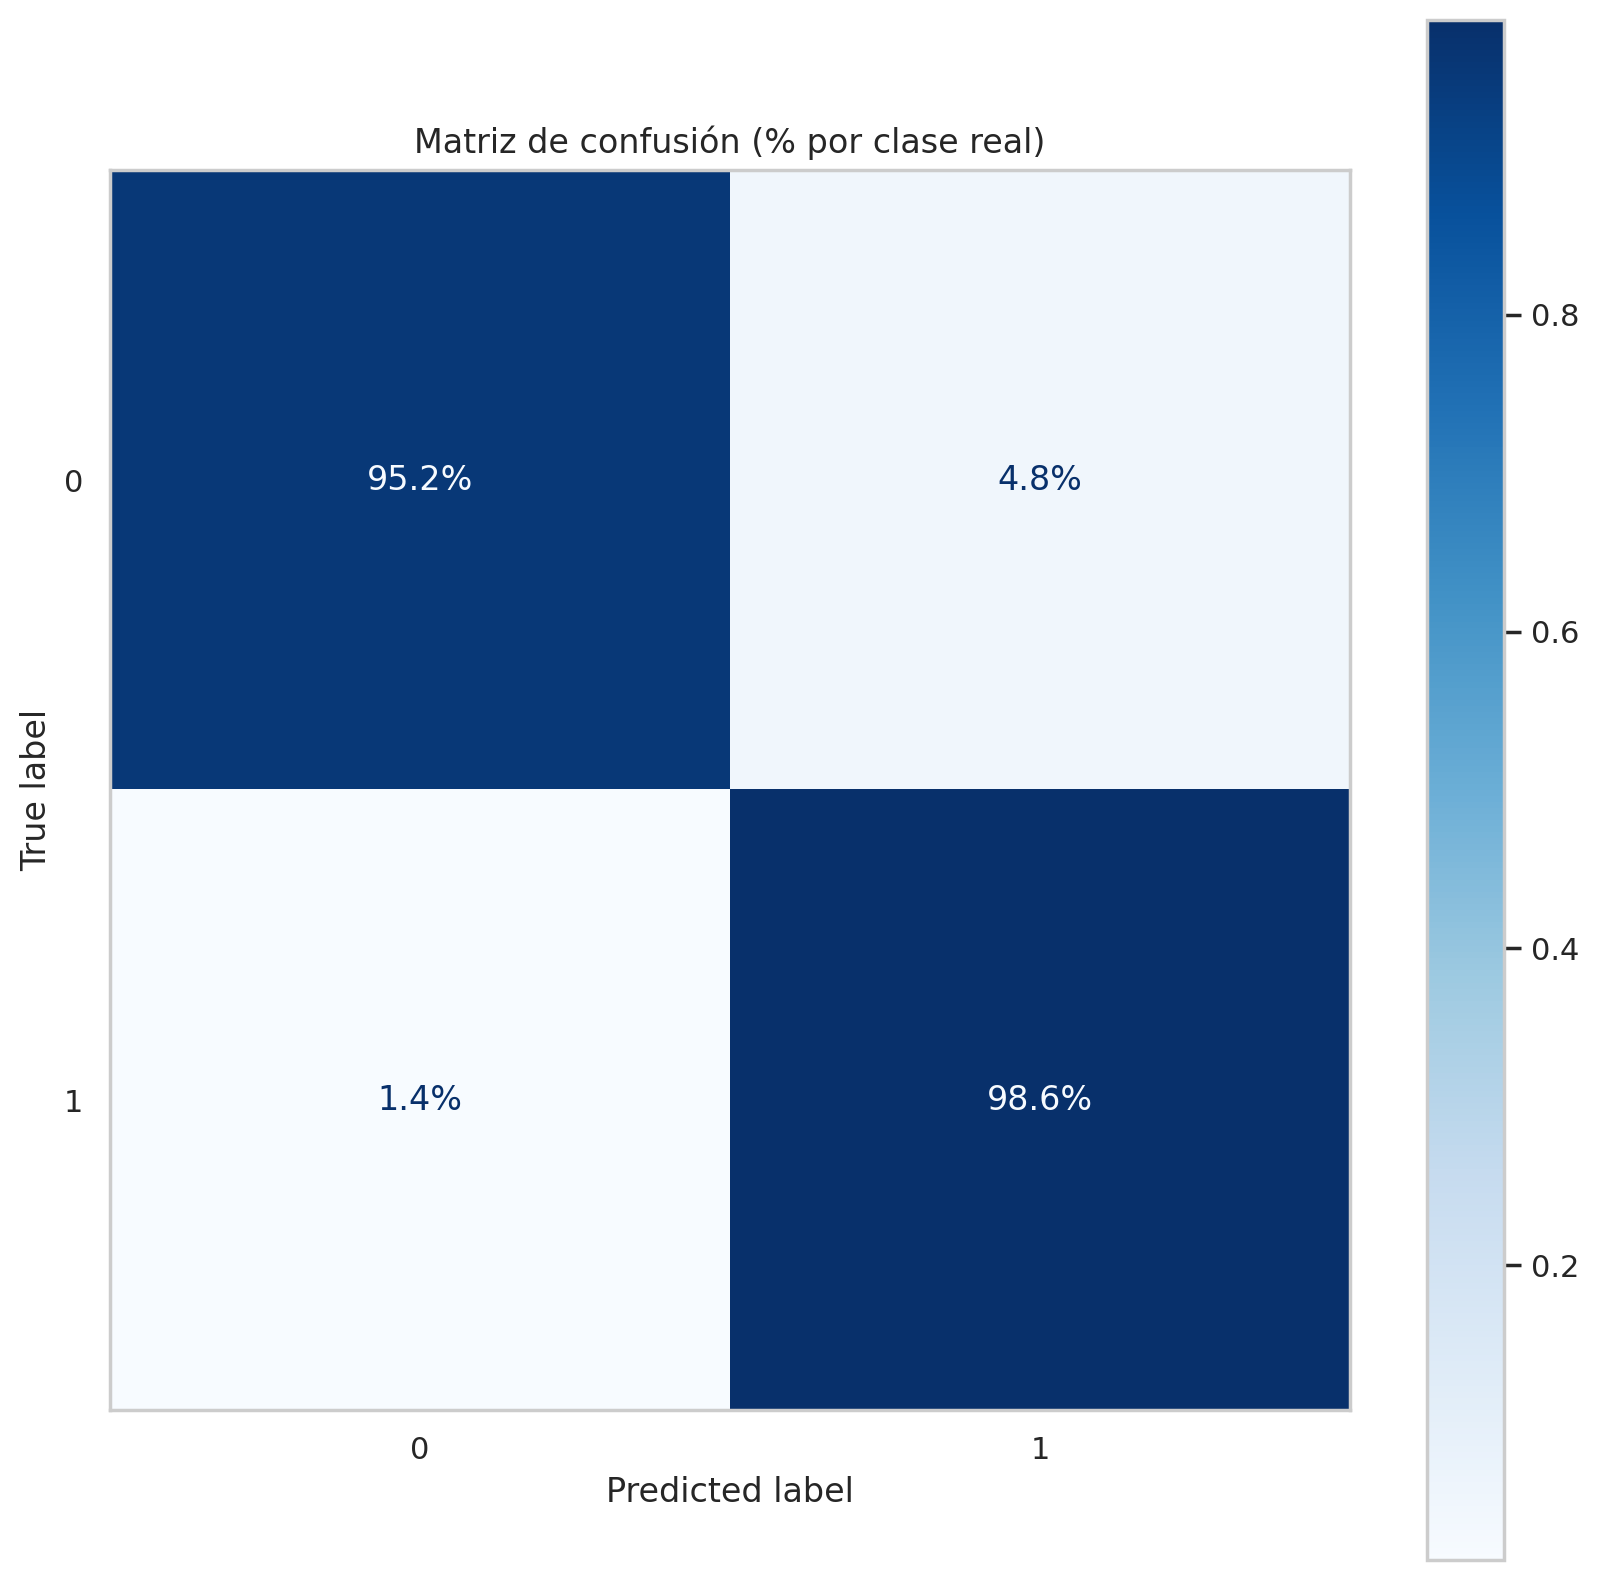

In [52]:
# Matriz de confusión (test) del modelo de 13 predictoras
matriz_confusion(modelo13, xtest[vars13], ytest);

In [53]:
# Validación cruzada (f1) del modelo de 13 predictoras
val13 = validar_modelo(modelo13, xtrain[vars13], ytrain, 'f1', 10)

Validacion cruzada (10 folds, score=f1): media = 0.983 +/- 0.016


El modelo con **13 predictoras** da una **matriz de confusión casi idéntica** a la del modelo completo (mismos ≈95 % de malignos y ≈99 % de benignos bien clasificados) y un f1 de validación cruzada (~0.978) muy próximo al de las 30 variables (~0.985), con desviación igual de pequeña. Confirma lo anticipado: **reducimos a menos de la mitad las variables sin perder capacidad de clasificación**, ganando simplicidad e interpretabilidad. Sería el modelo elegido si priorizamos la **explicabilidad**.



## <font color="steelblue">8.6. Preprocesado con componentes principales</font>

Como **todas las predictoras son numéricas** (y están estandarizadas), podemos reducir la dimensión con **Análisis de Componentes Principales (PCA)**: nuevas variables (componentes) **no correlacionadas** que concentran la varianza. Nos quedamos con las componentes necesarias para explicar **≥ 70 %** de la variabilidad y entrenamos el modelo sobre ellas.

Componentes para ≥70% de varianza: 3  (varianza acumulada = 72.9%)


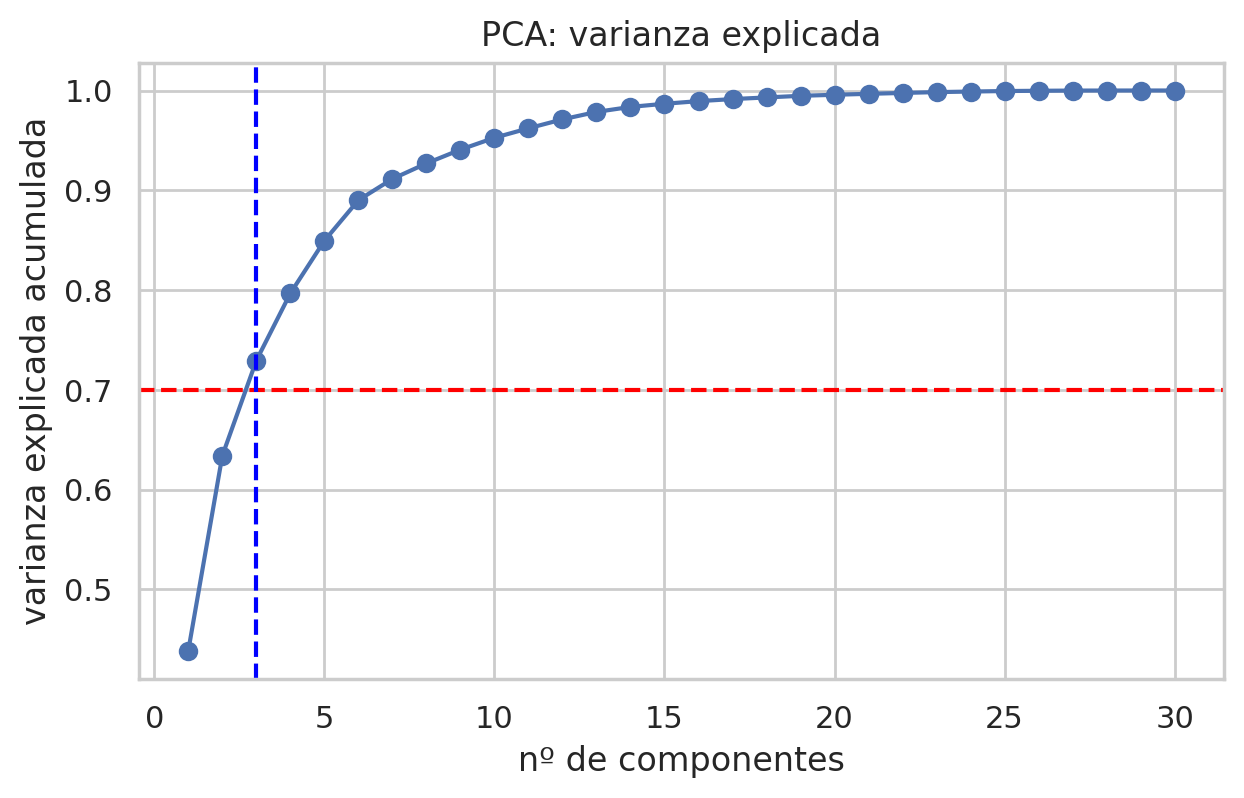

In [54]:
# PCA ajustado SOLO con el entrenamiento; nº de componentes para >=70% de varianza
pca_full = PCA().fit(xtrain)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)
k70 = int(np.argmax(var_acum >= 0.70) + 1)
print(f'Componentes para ≥70% de varianza: {k70}  (varianza acumulada = {var_acum[k70-1]:.1%})')

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(var_acum)+1), var_acum, 'o-')
plt.axhline(0.70, color='red', ls='--')
plt.axvline(k70, color='blue', ls='--')
plt.xlabel('nº de componentes')
plt.ylabel('varianza explicada acumulada')
plt.title('PCA: varianza explicada')
plt.show()

Visualizamos las **dos primeras componentes** coloreadas por el target para analizar **visualmente** el poder de clasificación.

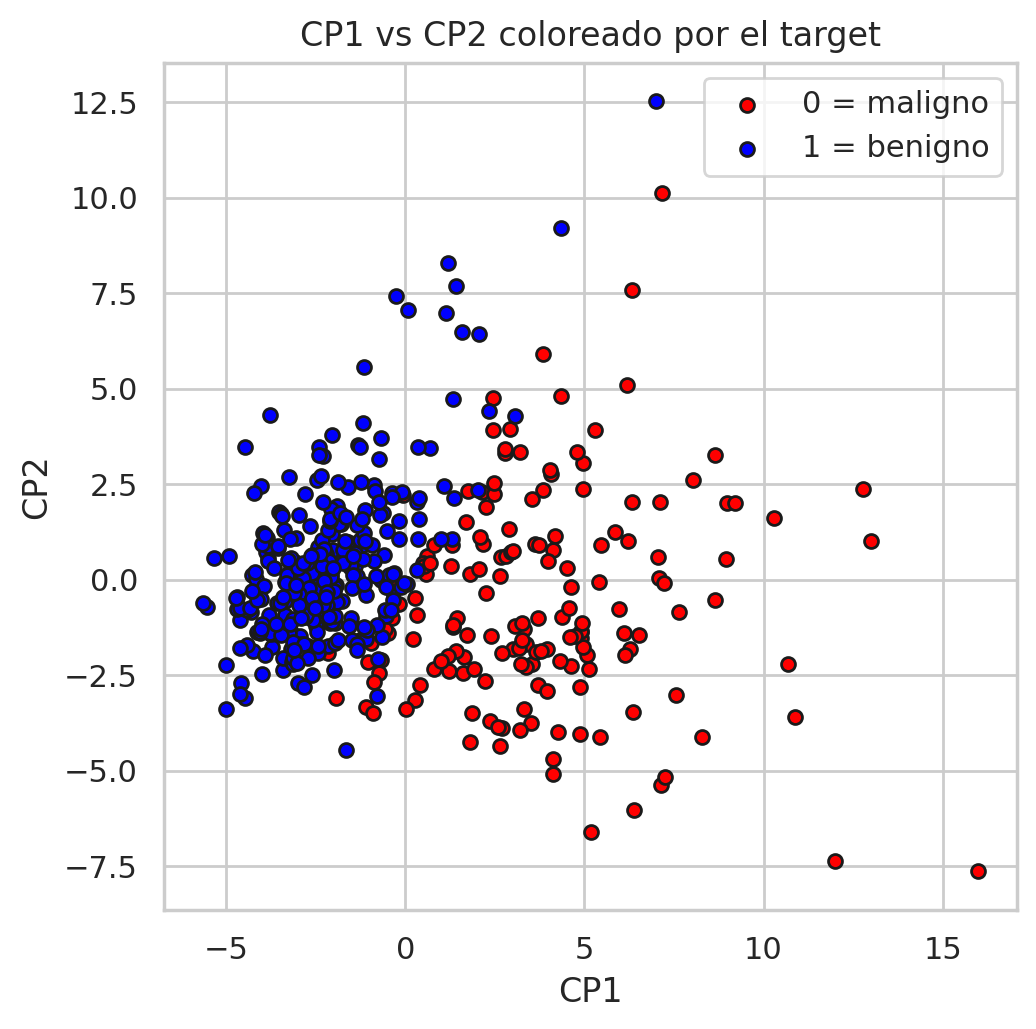

In [58]:
pca = PCA(n_components=k70).fit(xtrain)
Xtr_pca = pca.transform(xtrain); Xte_pca = pca.transform(xtest)

plt.figure(figsize=(5.5, 5.5))
plt.scatter(Xtr_pca[ytrain==0, 0], Xtr_pca[ytrain==0, 1], c='red', edgecolor='k', s=25, label='0 = maligno')
plt.scatter(Xtr_pca[ytrain==1, 0], Xtr_pca[ytrain==1, 1], c='blue', edgecolor='k', s=25, label='1 = benigno')
plt.xlabel('CP1')
plt.ylabel('CP2')
plt.title('CP1 vs CP2 coloreado por el target')
plt.legend()
plt.show()

En el plano **CP1–CP2** las dos clases aparecen **claramente separadas** (con una pequeña zona de solape): solo dos componentes ya captan la estructura que distingue malignos de benignos. Esto anticipa que un modelo entrenado sobre las componentes funcionará casi tan bien como el original. Lo comprobamos entrenando la regresión logística sobre las componentes principales extraídas.

In [60]:
modelo_pca = LogisticRegression(max_iter=5000).fit(Xtr_pca, ytrain)
print(f'=== Modelo sobre {k70} componentes principales ===')
print('Reporte (test):')
from sklearn.metrics import classification_report, f1_score
print(classification_report(ytest, modelo_pca.predict(Xte_pca), digits=3))
f1_pca = f1_score(ytest, modelo_pca.predict(Xte_pca), average='weighted')
f1_ori = f1_score(ytest, modelo.predict(xtest), average='weighted')
print(f'F1 (test) — original (30 variables): {f1_ori:.3f}  |  PCA ({k70} componentes): {f1_pca:.3f}')

=== Modelo sobre 3 componentes principales ===
Reporte (test):
              precision    recall  f1-score   support

           0      0.933     1.000     0.966        42
           1      1.000     0.958     0.979        72

    accuracy                          0.974       114
   macro avg      0.967     0.979     0.972       114
weighted avg      0.975     0.974     0.974       114

F1 (test) — original (30 variables): 0.974  |  PCA (3 componentes): 0.974


Con apenas **3 componentes** (≈73 % de la varianza) el modelo alcanza un **F1 prácticamente idéntico** al del modelo con las 30 variables originales. Es un resultado notable: la información relevante para clasificar está **muy concentrada** en pocas direcciones del espacio. A cambio, perdemos la **interpretabilidad directa** —las componentes son combinaciones de las 30 variables, no variables clínicas concretas, así que ya no hablamos de odds ratios por variable—. En resumen: **PCA** es excelente para **comprimir y visualizar** (y como preprocesado ante colinealidad), mientras que la **selección de variables** mantiene la interpretabilidad. La elección depende de si priorizamos **simplicidad numérica** o **explicabilidad**.

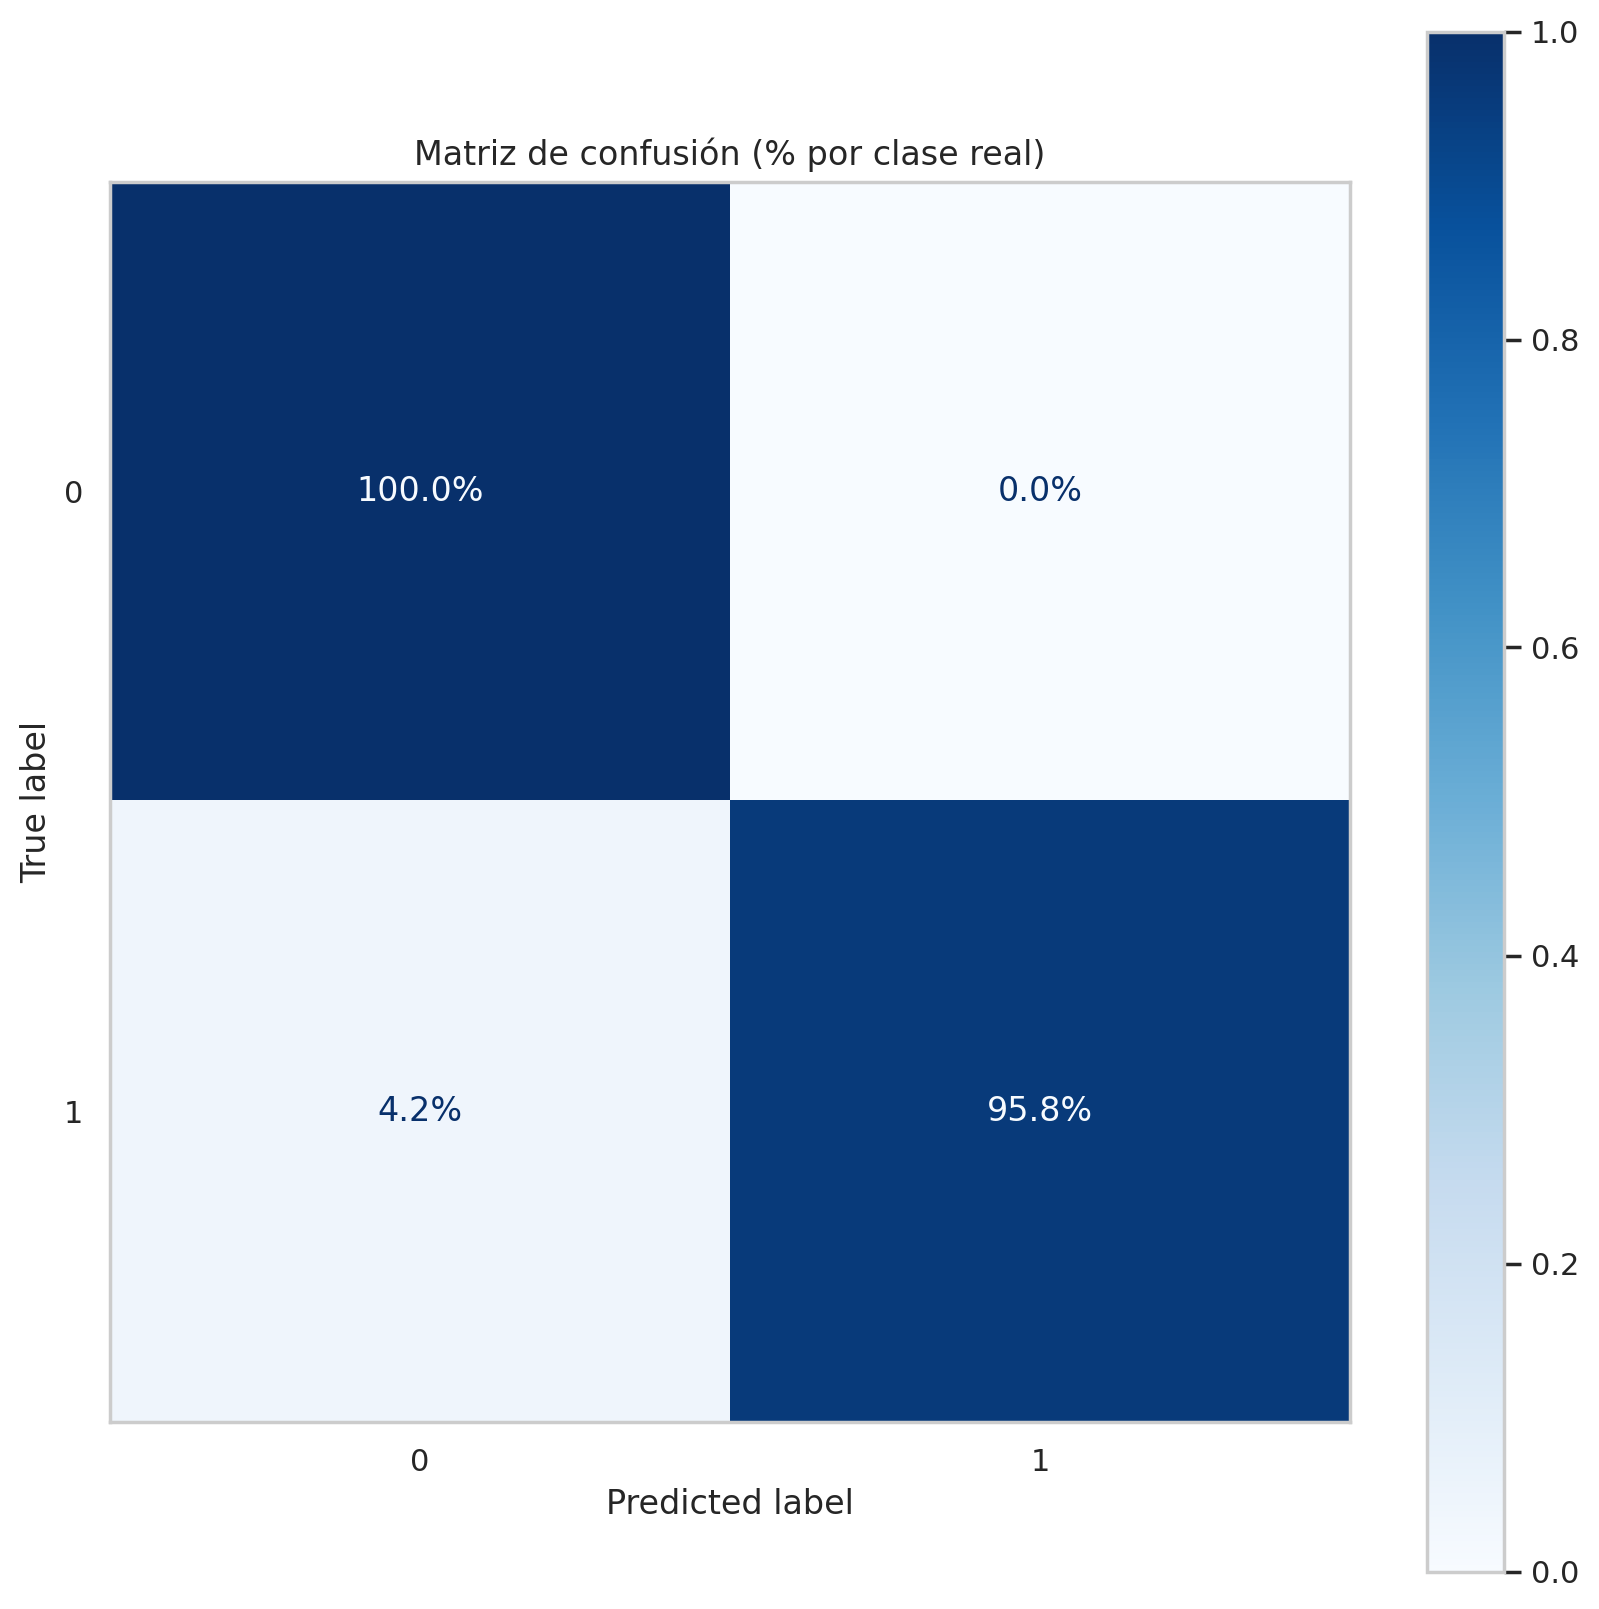

In [61]:
# Matriz de confusión (test) del modelo sobre componentes principales
matriz_confusion(modelo_pca, Xte_pca, ytest);

In [62]:
# Validación cruzada (f1) del modelo PCA
val_pca = validar_modelo(modelo_pca, Xtr_pca, ytrain, 'f1', 10)

Validacion cruzada (10 folds, score=f1): media = 0.959 +/- 0.026


La matriz de confusión revela un **perfil de errores distinto**: el modelo PCA clasifica correctamente **todos los malignos** (recall de la clase maligna = 100 %, **cero falsos negativos**) a costa de **algún falso positivo** más (un par de benignos marcados como malignos). En un contexto clínico esto es **interesante**, porque elimina precisamente el error más grave (no detectar un tumor maligno). En validación cruzada su f1 (0.96) queda algo por debajo del modelo de 30 variables (0.985) pero sigue siendo **alto y estable**: comprimir a 3 componentes cuesta muy poco. En conjunto, los tres modelos (30 variables, 13 variables y 3 componentes) son **competitivos**; la elección depende del equilibrio buscado entre **interpretabilidad**, **simplicidad** y el **tipo de error** a minimizar.

# <font color="steelblue">9. Optimización del modelo (hiperparámetros)</font>

Partimos del **modelo base** y buscamos con `GridSearchCV` la mejor combinación de los hiperparámetros influyentes (sección 4): `C`, `penalty` y un `solver` compatible. Elegimos la métrica `f1` por las razones de la sección 8.4.

In [63]:
pgrid = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
         'penalty': ['l1', 'l2'],
         'solver': ['saga']}
gs = GridSearchCV(LogisticRegression(max_iter=5000), pgrid, scoring='f1', cv=5)
gs.fit(xtrain, ytrain)
print('Mejores hiperparámetros:', gs.best_params_)
print(f'Mejor f1 (validación cruzada): {gs.best_score_:.4f}')

Mejores hiperparámetros: {'C': 1, 'penalty': 'l2', 'solver': 'saga'}
Mejor f1 (validación cruzada): 0.9896


Cuando el modelo base ya acierta mucho, la optimización aporta mejoras **pequeñas** en las métricas, pero tiene otras ventajas: conocer la **`C` óptima** dice cuánta regularización necesita el problema, y si gana **`penalty='l1'`** el modelo final usa **menos variables** (más simple). La receta general es siempre: **modelo base → rejilla de `C`/`penalty`/`solver` con `GridSearchCV` → comparar con el base en test** (añadiendo `class_weight='balanced'` si el desbalanceo fuera importante).

Entrenamos y validamos el modelo óptimo:

In [64]:
modelo_opt = gs.best_estimator_
print('=== Modelo OPTIMIZADO ===')
reports_clas(modelo_opt, xtrain, ytrain, xtest, ytest)
no_nulos = int((modelo_opt.coef_.flatten() != 0).sum())
print(f'Variables con coeficiente no nulo: {no_nulos} de {xtrain.shape[1]}')

=== Modelo OPTIMIZADO ===
Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       170
           1       0.98      1.00      0.99       285

    accuracy                           0.99       455
   macro avg       0.99      0.99      0.99       455
weighted avg       0.99      0.99      0.99       455


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        42
           1       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Variables con coeficiente no nulo: 30 de 30


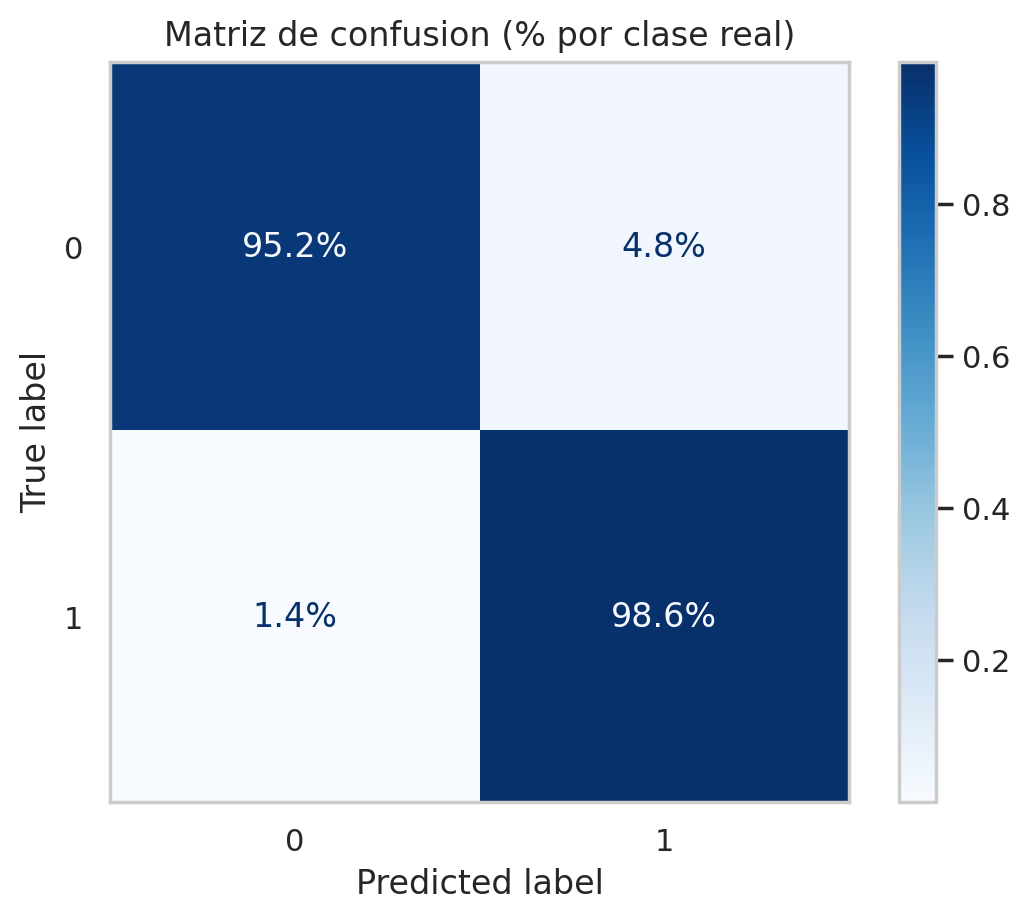

In [ ]:
matriz_confusion(modelo_opt, xtest, ytest);

In [ ]:
val_opt = validar_modelo(modelo_opt, xtrain, ytrain, 'f1', 10)

Validacion cruzada (10 folds, score=f1): media = 0.9823 +/- 0.0132


# <font color="steelblue">10. Corrección del desbalanceo: ponderación de clases</font>

El target está **desequilibrado** (~63 % benignos / ~37 % malignos), y la clase **minoritaria** (maligna) es justamente la que más nos importa acertar. Un modelo que minimiza el error global puede "descuidar" la clase minoritaria. Una forma directa de corregirlo —sin tocar los datos— es **ponderar las clases**: con **`class_weight='balanced'`**, scikit-learn asigna a cada clase un peso **inversamente proporcional a su frecuencia**,

$$w_c = \frac{n}{K\cdot n_c},$$

de modo que **cada error en la clase minoritaria penaliza más** en la *log-loss*. El modelo "presta así más atención" a los malignos. Lo entrenamos y analizamos su matriz de confusión y su validación.

In [65]:
modelo_bal = LogisticRegression(max_iter=5000, class_weight='balanced').fit(xtrain, ytrain)
print('=== Modelo con class_weight="balanced" ===')
reports_clas(modelo_bal, xtrain, ytrain, xtest, ytest)

=== Modelo con class_weight="balanced" ===
Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       170
           1       0.99      0.99      0.99       285

    accuracy                           0.99       455
   macro avg       0.99      0.98      0.99       455
weighted avg       0.99      0.99      0.99       455


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        42
           1       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



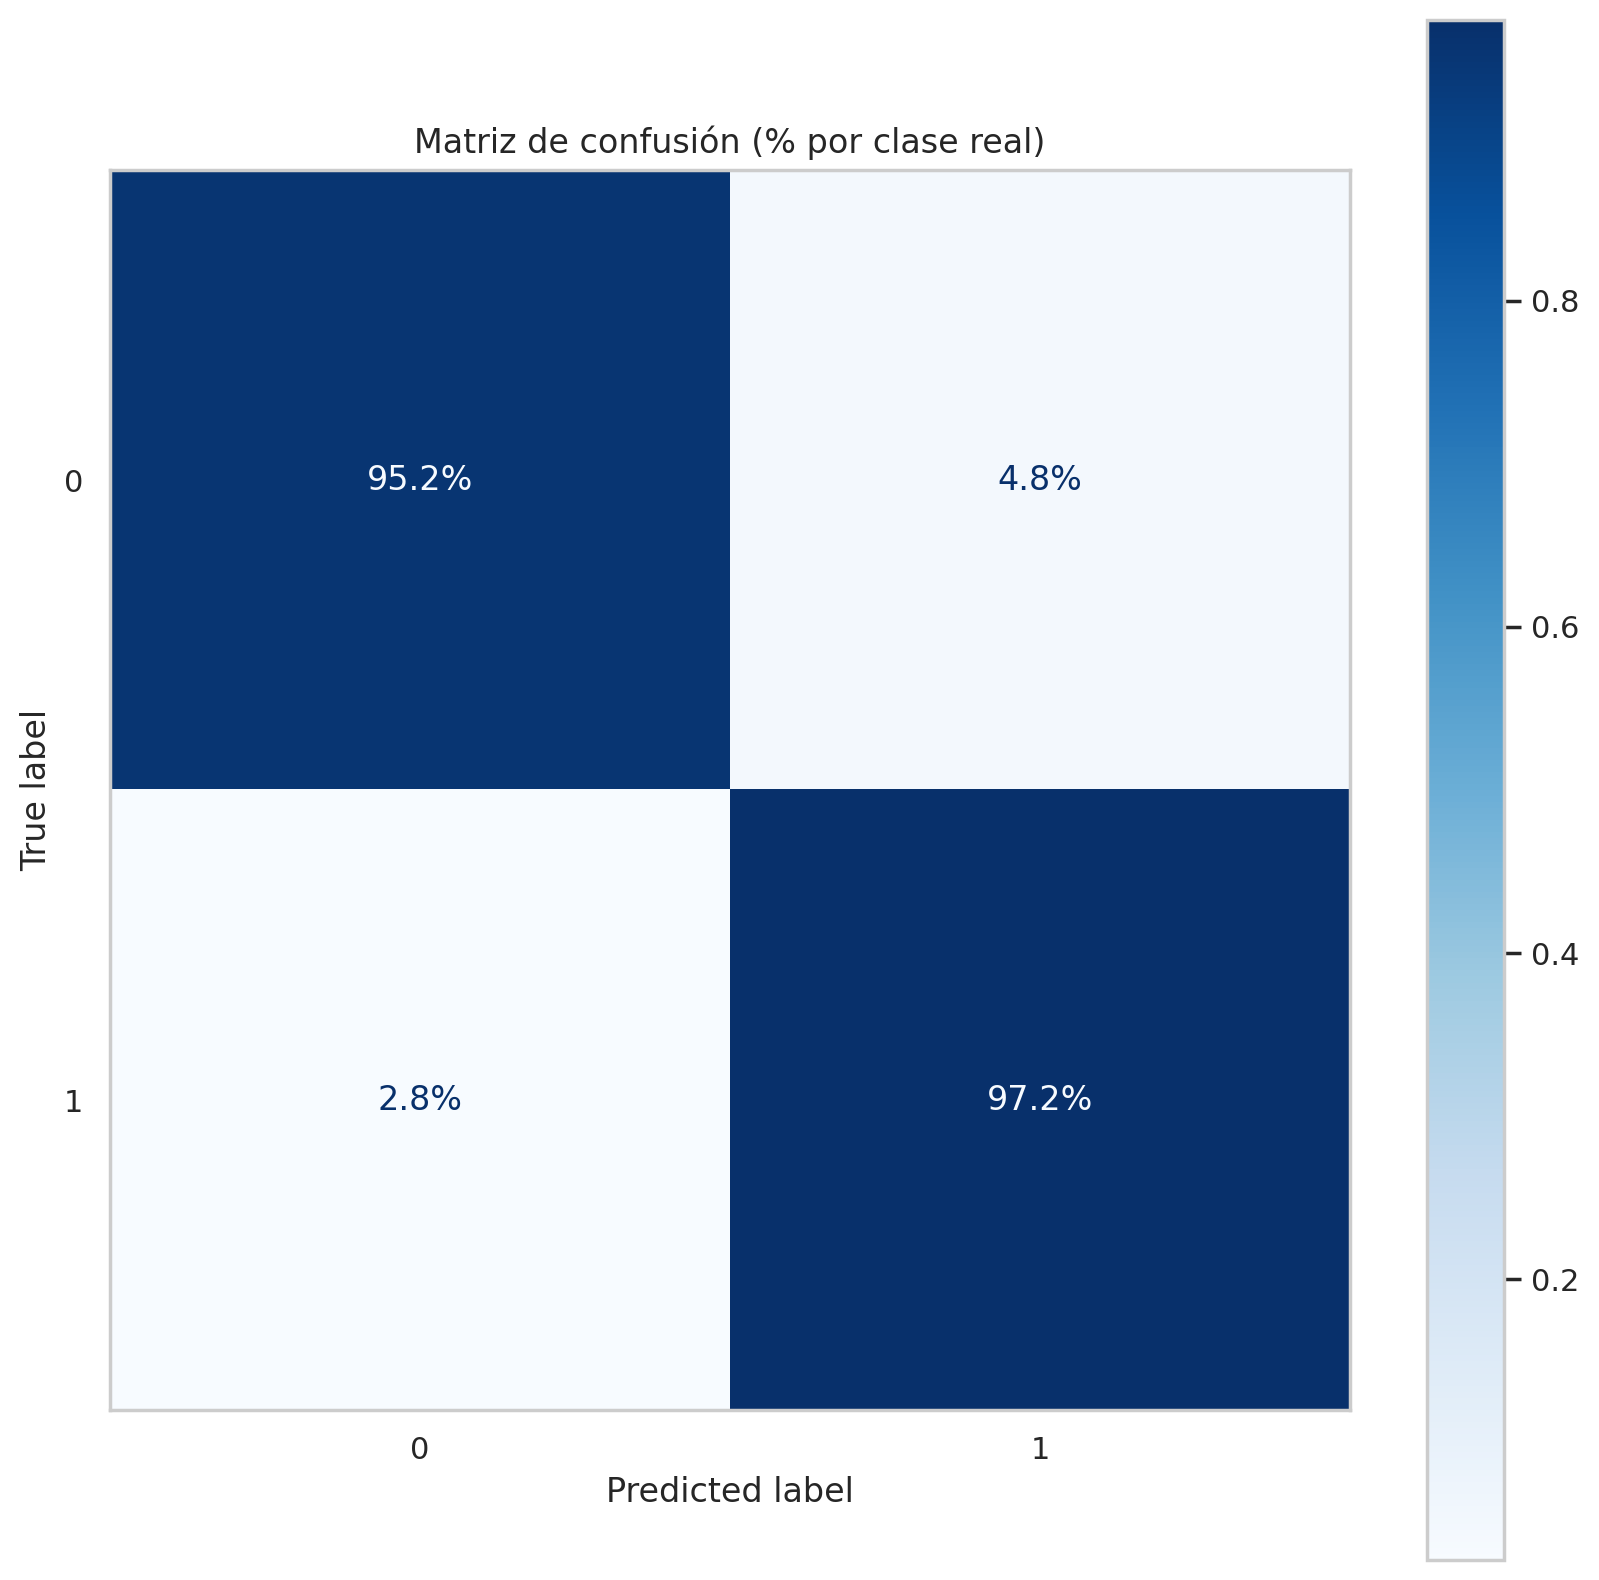

In [66]:
# Matriz de confusión (test) del modelo ponderado
matriz_confusion(modelo_bal, xtest, ytest);

In [ ]:
# Validación cruzada (f1) del modelo ponderado
val_bal = validar_modelo(modelo_bal, xtrain, ytrain, 'f1', 10)

Validacion cruzada (10 folds, score=f1): media = 0.9757 +/- 0.0154


La ponderación es la **herramienta correcta** ante el desbalanceo: reequilibra el coste de los errores hacia la clase minoritaria (maligna). En **este** conjunto, sin embargo, su efecto es **pequeño**: como el desbalanceo es solo moderado (63/37) y el modelo base ya clasificaba muy bien a los malignos, la matriz de confusión apenas cambia (el *recall* de la clase maligna se mantiene en 95 %) y el f1 de validación queda casi igual (0.978), incluso puede bajar levemente al convertir algún benigno en falso positivo. La lectura es doble: (1) **cuándo usarla** —es imprescindible cuando el desbalanceo es **severo** (p. ej. 95/5) o el coste de fallar en la minoritaria es muy alto—; y (2) **qué esperar** —no es magia: si el modelo ya trataba bien a la minoría, ponderar aporta poco—. Si el objetivo es **reducir los falsos negativos** de forma garantizada, suele ser más efectivo **combinar** la ponderación con un **ajuste del umbral** de decisión (sección 5) u optimizar directamente el *recall* de la clase maligna (`scoring='recall'`).



# <font color="steelblue">11. Referencias</font>

* Hosmer, Lemeshow & Sturdivant (2013). *Applied Logistic Regression*. Wiley.
* Hastie, Tibshirani & Friedman (2009). *The Elements of Statistical Learning* (cap. 4). Springer.
* James, Witten, Hastie & Tibshirani (2021). *An Introduction to Statistical Learning* (cap. 4).
* Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow*. O'Reilly.
* scikit-learn — *Logistic Regression*: https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression